In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import plotly.graph_objects as go
from scipy.stats import ttest_ind

# Set random seed for reproducibility
np.random.seed(42)

In [3]:
pd.set_option("display.max_rows", 11)

In [4]:
from datetime import datetime

In [5]:
date = datetime.today().strftime('%m%d')
num = 1

In [12]:
cancer = "LGG"

In [13]:
cancer_data = pd.read_csv(f"{cancer}_Normed_Entire_Data_Sex_E_T.csv")
cancer_data

,HMGB1P1,A2M,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASDH,AASS,ABAT,...,ZMAT3,ZNF274,ZNRF3,ZW10,ZWILCH,ZWINT,ZYX,Sex,OS_STATUS,OS_MONTHS
0,1.777716,0.389232,-1.177514,0.517646,-0.527263,0.475746,-1.120785,0.469608,-0.263035,0.845147,...,-0.578702,1.071558,0.765242,-0.439994,-1.164296,-1.448524,-0.809574,0,0,117.41
1,0.233934,0.707874,-0.794603,-0.908896,0.586772,-0.776142,-0.485973,-0.160776,0.959209,0.646833,...,0.486913,-0.527983,0.277609,-0.035972,0.323295,-0.505197,0.818143,1,1,7.69
2,0.711468,0.824952,-0.271857,1.699544,-0.146400,-1.522602,0.322414,-0.092264,-1.469562,-0.260285,...,0.508958,-0.842355,-0.304808,0.249729,-0.458007,0.128614,-0.213299,0,1,43.86
3,1.791092,0.007414,-0.303279,-0.655909,-1.619284,0.736664,0.497619,-1.197012,-1.604390,-0.459375,...,-0.325959,1.012508,-1.208278,1.686594,2.562832,2.373111,-0.283270,1,1,36.33
4,1.157604,-0.112626,-0.342409,-1.595685,-0.101821,-0.458447,-0.456942,-0.001335,-2.456418,0.024421,...,-0.962883,-1.490118,0.266920,-0.494128,-1.748391,-1.310929,-0.705312,1,0,60.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,-0.399459,-1.481720,2.889208,-0.322603,-0.221191,1.158866,0.301227,-0.936558,0.256070,-0.789024,...,-1.715259,-1.081246,0.072150,-0.608469,0.286122,0.132115,-0.470074,0,0,39.85
242,-0.413783,-0.370962,-0.024195,1.461690,0.159579,-0.219504,-0.095633,0.518314,0.278427,0.283403,...,-0.081157,1.076537,0.171947,-1.680221,-0.745575,-0.659906,-0.929458,1,0,43.36
243,-0.218842,0.715807,-0.877743,1.792280,-0.769873,0.728809,0.759816,0.728172,0.676274,-0.173310,...,-1.197759,1.242038,-1.331913,1.028516,0.769277,0.889907,-0.837304,1,0,45.76
244,-0.506558,-0.106510,-0.508298,1.856691,0.339280,0.724135,1.219016,0.623828,0.863336,0.192061,...,-1.414768,2.049526,0.537743,2.332232,-0.836792,-0.923038,-0.467301,1,0,46.85


In [14]:
cancer_data['Sex'] = cancer_data['Sex'].apply(lambda x: 'Male' if x == 1 else 'Female')

In [15]:
cancer_data

,HMGB1P1,A2M,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASDH,AASS,ABAT,...,ZMAT3,ZNF274,ZNRF3,ZW10,ZWILCH,ZWINT,ZYX,Sex,OS_STATUS,OS_MONTHS
0,1.777716,0.389232,-1.177514,0.517646,-0.527263,0.475746,-1.120785,0.469608,-0.263035,0.845147,...,-0.578702,1.071558,0.765242,-0.439994,-1.164296,-1.448524,-0.809574,Female,0,117.41
1,0.233934,0.707874,-0.794603,-0.908896,0.586772,-0.776142,-0.485973,-0.160776,0.959209,0.646833,...,0.486913,-0.527983,0.277609,-0.035972,0.323295,-0.505197,0.818143,Male,1,7.69
2,0.711468,0.824952,-0.271857,1.699544,-0.146400,-1.522602,0.322414,-0.092264,-1.469562,-0.260285,...,0.508958,-0.842355,-0.304808,0.249729,-0.458007,0.128614,-0.213299,Female,1,43.86
3,1.791092,0.007414,-0.303279,-0.655909,-1.619284,0.736664,0.497619,-1.197012,-1.604390,-0.459375,...,-0.325959,1.012508,-1.208278,1.686594,2.562832,2.373111,-0.283270,Male,1,36.33
4,1.157604,-0.112626,-0.342409,-1.595685,-0.101821,-0.458447,-0.456942,-0.001335,-2.456418,0.024421,...,-0.962883,-1.490118,0.266920,-0.494128,-1.748391,-1.310929,-0.705312,Male,0,60.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,-0.399459,-1.481720,2.889208,-0.322603,-0.221191,1.158866,0.301227,-0.936558,0.256070,-0.789024,...,-1.715259,-1.081246,0.072150,-0.608469,0.286122,0.132115,-0.470074,Female,0,39.85
242,-0.413783,-0.370962,-0.024195,1.461690,0.159579,-0.219504,-0.095633,0.518314,0.278427,0.283403,...,-0.081157,1.076537,0.171947,-1.680221,-0.745575,-0.659906,-0.929458,Male,0,43.36
243,-0.218842,0.715807,-0.877743,1.792280,-0.769873,0.728809,0.759816,0.728172,0.676274,-0.173310,...,-1.197759,1.242038,-1.331913,1.028516,0.769277,0.889907,-0.837304,Male,0,45.76
244,-0.506558,-0.106510,-0.508298,1.856691,0.339280,0.724135,1.219016,0.623828,0.863336,0.192061,...,-1.414768,2.049526,0.537743,2.332232,-0.836792,-0.923038,-0.467301,Male,0,46.85


In [16]:
cancer_data = cancer_data.rename(columns={'OS_STATUS': 'E', 'OS_MONTHS': 'T'})
cancer_data

,HMGB1P1,A2M,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASDH,AASS,ABAT,...,ZMAT3,ZNF274,ZNRF3,ZW10,ZWILCH,ZWINT,ZYX,Sex,E,T
0,1.777716,0.389232,-1.177514,0.517646,-0.527263,0.475746,-1.120785,0.469608,-0.263035,0.845147,...,-0.578702,1.071558,0.765242,-0.439994,-1.164296,-1.448524,-0.809574,Female,0,117.41
1,0.233934,0.707874,-0.794603,-0.908896,0.586772,-0.776142,-0.485973,-0.160776,0.959209,0.646833,...,0.486913,-0.527983,0.277609,-0.035972,0.323295,-0.505197,0.818143,Male,1,7.69
2,0.711468,0.824952,-0.271857,1.699544,-0.146400,-1.522602,0.322414,-0.092264,-1.469562,-0.260285,...,0.508958,-0.842355,-0.304808,0.249729,-0.458007,0.128614,-0.213299,Female,1,43.86
3,1.791092,0.007414,-0.303279,-0.655909,-1.619284,0.736664,0.497619,-1.197012,-1.604390,-0.459375,...,-0.325959,1.012508,-1.208278,1.686594,2.562832,2.373111,-0.283270,Male,1,36.33
4,1.157604,-0.112626,-0.342409,-1.595685,-0.101821,-0.458447,-0.456942,-0.001335,-2.456418,0.024421,...,-0.962883,-1.490118,0.266920,-0.494128,-1.748391,-1.310929,-0.705312,Male,0,60.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,-0.399459,-1.481720,2.889208,-0.322603,-0.221191,1.158866,0.301227,-0.936558,0.256070,-0.789024,...,-1.715259,-1.081246,0.072150,-0.608469,0.286122,0.132115,-0.470074,Female,0,39.85
242,-0.413783,-0.370962,-0.024195,1.461690,0.159579,-0.219504,-0.095633,0.518314,0.278427,0.283403,...,-0.081157,1.076537,0.171947,-1.680221,-0.745575,-0.659906,-0.929458,Male,0,43.36
243,-0.218842,0.715807,-0.877743,1.792280,-0.769873,0.728809,0.759816,0.728172,0.676274,-0.173310,...,-1.197759,1.242038,-1.331913,1.028516,0.769277,0.889907,-0.837304,Male,0,45.76
244,-0.506558,-0.106510,-0.508298,1.856691,0.339280,0.724135,1.219016,0.623828,0.863336,0.192061,...,-1.414768,2.049526,0.537743,2.332232,-0.836792,-0.923038,-0.467301,Male,0,46.85


In [10]:
pathway_list = pd.read_csv("/home/koe3/Bioinformatics/Data/pathway_list.txt", header=None).values.ravel()

In [34]:
pathway_list

array(['KEGG_ABC_TRANSPORTERS', 'KEGG_ACUTE_MYELOID_LEUKEMIA',
       'KEGG_ADHERENS_JUNCTION', 'KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY',
       'KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM',
       'KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION',
       'KEGG_ALLOGRAFT_REJECTION', 'KEGG_ALPHA_LINOLENIC_ACID_METABOLISM',
       'KEGG_ALZHEIMERS_DISEASE', 'KEGG_AMINOACYL_TRNA_BIOSYNTHESIS',
       'KEGG_AMINO_SUGAR_AND_NUCLEOTIDE_SUGAR_METABOLISM',
       'KEGG_AMYOTROPHIC_LATERAL_SCLEROSIS_ALS',
       'KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION', 'KEGG_APOPTOSIS',
       'KEGG_ARACHIDONIC_ACID_METABOLISM',
       'KEGG_ARGININE_AND_PROLINE_METABOLISM',
       'KEGG_ARRHYTHMOGENIC_RIGHT_VENTRICULAR_CARDIOMYOPATHY_ARVC',
       'KEGG_ASCORBATE_AND_ALDARATE_METABOLISM', 'KEGG_ASTHMA',
       'KEGG_AUTOIMMUNE_THYROID_DISEASE', 'KEGG_AXON_GUIDANCE',
       'KEGG_BASAL_CELL_CARCINOMA', 'KEGG_BASAL_TRANSCRIPTION_FACTORS',
       'KEGG_BASE_EXCISION_REPAIR', 'KEGG_BETA_ALANINE_METABOLISM',
 

In [47]:
avg_cmn_pathwy_node = pd.read_csv(f"Opt_Params/[0825_1]AVG_Common_Pathway_Nodes.csv", header=None, names=pathway_list)
avg_male_pathwy_node = pd.read_csv(f"Opt_Params/[0825_1]AVG_Male_Pathway_Nodes.csv", header=None, names=pathway_list)
avg_female_pathwy_node = pd.read_csv(f"Opt_Params/[0825_1]AVG_Female_Pathway_Nodes.csv", header=None, names=pathway_list)

In [48]:
avg_cmn_pathwy_node

,KEGG_ABC_TRANSPORTERS,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_ADHERENS_JUNCTION,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,KEGG_ALLOGRAFT_REJECTION,KEGG_ALPHA_LINOLENIC_ACID_METABOLISM,KEGG_ALZHEIMERS_DISEASE,KEGG_AMINOACYL_TRNA_BIOSYNTHESIS,...,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_PRKAR1A_TO_CRHR_PKA_ACTH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_PTCH1_TO_HEDGEHOG_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_RASD1_TO_CRHR_PKA_ACTH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_UBQLN2_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_VCP_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_NOTCH_OVEREXPRESSION_TO_NOTCH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_MGLUR5_CA2_APOPTOTIC_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_PRNP_PI3K_NOX2_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_TRANSPORT_OF_CALCIUM
0,0.683213,0.514171,0.578608,0.587484,0.449794,0.433951,0.524439,0.539809,0.529087,0.420925,...,0.517263,0.499926,0.539661,0.580610,0.583664,0.558768,0.417909,0.628376,0.660132,0.636086
1,0.434015,0.514135,0.335726,0.453198,0.487778,0.468067,0.554346,0.488952,0.503196,0.495113,...,0.464843,0.566656,0.464296,0.480827,0.404889,0.388470,0.502988,0.382557,0.529002,0.321167
2,0.538386,0.546358,0.604165,0.599589,0.451555,0.507545,0.463738,0.498062,0.533909,0.498195,...,0.519545,0.511844,0.469969,0.628185,0.618340,0.561239,0.512248,0.553710,0.648872,0.518503
3,0.586092,0.492039,0.622602,0.517403,0.462460,0.528874,0.435509,0.499667,0.521072,0.545186,...,0.526505,0.536990,0.469150,0.560253,0.686705,0.522072,0.384217,0.582695,0.603012,0.533624
4,0.508797,0.511708,0.503577,0.630034,0.484878,0.439198,0.421566,0.528024,0.448724,0.516240,...,0.528351,0.478097,0.550390,0.526538,0.603592,0.522944,0.569553,0.653005,0.491269,0.625048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,0.455903,0.511944,0.618153,0.424095,0.507763,0.494694,0.445431,0.470774,0.473497,0.539192,...,0.533555,0.468198,0.477328,0.521577,0.541170,0.613631,0.463247,0.666443,0.540011,0.645775
242,0.537582,0.504802,0.670132,0.505483,0.491469,0.422493,0.548156,0.447654,0.441905,0.483172,...,0.487547,0.563151,0.518953,0.569822,0.575625,0.628680,0.517497,0.524066,0.612285,0.607768
243,0.538661,0.615263,0.648553,0.581257,0.494176,0.471492,0.515036,0.547903,0.442670,0.491741,...,0.457879,0.429933,0.486165,0.524175,0.540405,0.618774,0.509258,0.552444,0.579363,0.618210
244,0.518734,0.659419,0.576161,0.443729,0.471102,0.520864,0.464131,0.485664,0.447594,0.456102,...,0.486847,0.521520,0.427995,0.481305,0.628820,0.532437,0.517643,0.540213,0.512065,0.621165


In [49]:
avg_male_pathwy_node

,KEGG_ABC_TRANSPORTERS,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_ADHERENS_JUNCTION,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,KEGG_ALLOGRAFT_REJECTION,KEGG_ALPHA_LINOLENIC_ACID_METABOLISM,KEGG_ALZHEIMERS_DISEASE,KEGG_AMINOACYL_TRNA_BIOSYNTHESIS,...,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_PRKAR1A_TO_CRHR_PKA_ACTH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_PTCH1_TO_HEDGEHOG_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_RASD1_TO_CRHR_PKA_ACTH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_UBQLN2_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_VCP_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_NOTCH_OVEREXPRESSION_TO_NOTCH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_MGLUR5_CA2_APOPTOTIC_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_PRNP_PI3K_NOX2_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_TRANSPORT_OF_CALCIUM
0,0.482712,0.329488,0.429430,0.354916,0.528444,0.476480,0.447123,0.516367,0.461616,0.464058,...,0.473423,0.580800,0.567045,0.538616,0.538609,0.430794,0.454454,0.411953,0.487369,0.390667
1,0.545238,0.741488,0.556874,0.540031,0.472282,0.524944,0.489777,0.463531,0.554741,0.588526,...,0.478594,0.456648,0.443947,0.486121,0.490759,0.444119,0.518454,0.546891,0.506774,0.468951
2,0.374661,0.563542,0.568042,0.546429,0.515929,0.403383,0.477217,0.475232,0.521999,0.496462,...,0.461236,0.443762,0.466584,0.558321,0.542121,0.514408,0.521229,0.506971,0.529099,0.499172
3,0.531815,0.608084,0.504930,0.452523,0.537763,0.515678,0.524114,0.523328,0.483226,0.603702,...,0.488461,0.480083,0.537334,0.504148,0.521609,0.526430,0.571438,0.502441,0.499377,0.479142
4,0.586583,0.374604,0.438736,0.545365,0.472248,0.469207,0.495582,0.501800,0.528228,0.434175,...,0.451135,0.510534,0.401997,0.534933,0.501980,0.407060,0.428638,0.396598,0.432253,0.426516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,0.482117,0.584293,0.489324,0.495991,0.497992,0.509838,0.570657,0.483225,0.477345,0.595470,...,0.501315,0.491011,0.487078,0.447288,0.504430,0.512047,0.504074,0.463233,0.431370,0.474499
137,0.544715,0.737506,0.556080,0.477027,0.515570,0.506269,0.520321,0.467706,0.569375,0.507849,...,0.475139,0.435204,0.469380,0.493901,0.491660,0.513129,0.499996,0.532065,0.501709,0.480193
138,0.514818,0.680746,0.544960,0.559732,0.526178,0.471794,0.500145,0.460973,0.514265,0.574120,...,0.469958,0.468271,0.445158,0.452944,0.471527,0.538066,0.566443,0.559495,0.525594,0.498231
139,0.593544,0.610844,0.573997,0.448323,0.500771,0.450965,0.514354,0.426960,0.450209,0.576218,...,0.499161,0.476586,0.612129,0.448162,0.523668,0.577503,0.555633,0.572210,0.537800,0.545032


In [120]:
top_common_pathways = ['KEGG_MEDICUS_VARIANT_NOTCH_OVEREXPRESSION_TO_NOTCH_SIGNALING_PATHWAY',
       'KEGG_ABC_TRANSPORTERS',
       'KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_UBQLN2_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION',
       'KEGG_ADHERENS_JUNCTION',
       'KEGG_MEDICUS_VARIANT_MUTATION_ACTIVATED_GNAS_TO_CRHR_PKA_ACTH_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_WNT5A_ROR_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_WNT_SIGNALING_MODULATION_WNT_ACYLATION',
       'KEGG_MEDICUS_REFERENCE_WNT_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_VARIANT_CYP11B1_CYP11B2_FUSION_TO_ACTH_CORTISOL_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_VARIANT_FZD7_OVEREXPRESSION_TO_WNT_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_TNF_P38_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_TRANSCRIPTION_COUPLED_NER',
       'KEGG_MEDICUS_REFERENCE_TRANSLATION_INITIATION',
       'KEGG_MEDICUS_REFERENCE_TSH_TG_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_TYPE_I_IFN_SIGNALING_PATHWAY']

In [121]:
top_male_pathways = ['KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_ABETA_TO_ELECTRON_TRANSFER_IN_COMPLEX_IV',
       'KEGG_MEDICUS_REFERENCE_TRAIP_DEPENDENT_REPLISOME_DISASSEMBLY',
       'KEGG_BASE_EXCISION_REPAIR',
       'KEGG_MEDICUS_REFERENCE_GF_RTK_PI3K_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_TIGHT_JUNCTION_ACTIN_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_GLOBAL_GENOME_NER',
       'KEGG_MEDICUS_PATHOGEN_HTLV_1_TAX_TO_SPINDLE_ASSEMBLY_CHECKPOINT_SIGNALING',
       'KEGG_MEDICUS_REFERENCE_IFN_RIPK1_3_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_TUBA4A_TO_RETROGRADE_AXONAL_TRANSPORT',
       'KEGG_MEDICUS_REFERENCE_ORGANIZATION_OF_THE_OUTER_KINETOCHORE',
       'KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_PTCH1_TO_HEDGEHOG_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_TNF_P38_SIGNALING_PATHWAY',
       'KEGG_VIBRIO_CHOLERAE_INFECTION', 'KEGG_MELANOGENESIS',
       'KEGG_MEDICUS_REFERENCE_DISASSEMBLY_OF_MCC']

In [122]:
top_female_pathways = ['KEGG_MEDICUS_PATHOGEN_ESCHERICHIA_EAE_TIR_TO_ACTIN_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_CX3CR1_GNAI_AC_PKA_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_ACTIVATION_OF_PRC2.2_BY_UBIQUITINATION_OF_H2AK119',
       'KEGG_MEDICUS_PATHOGEN_HIV_TAT_TO_TLR2_4_NFKB_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_VARIANT_FZD7_OVEREXPRESSION_TO_WNT_SIGNALING_PATHWAY',
       'KEGG_ASTHMA',
       'KEGG_MEDICUS_REFERENCE_HOMOLOGOUS_RECOMBINATION_IN_ICLR',
       'KEGG_MEDICUS_REFERENCE_KEAP1_NRF2_SIGNALING_PATHWAY',
       'KEGG_MEDICUS_REFERENCE_ORGANIZATION_OF_THE_OUTER_KINETOCHORE',
       'KEGG_MEDICUS_REFERENCE_TIGHT_JUNCTION_ACTIN_SIGNALING_PATHWAY',
       'KEGG_B_CELL_RECEPTOR_SIGNALING_PATHWAY',
       'KEGG_NICOTINATE_AND_NICOTINAMIDE_METABOLISM',
       'KEGG_MEDICUS_REFERENCE_ITGA_B_FAK_RAC_SIGNALING_PATHWAY',
       'KEGG_AMYOTROPHIC_LATERAL_SCLEROSIS_ALS',
       'KEGG_MEDICUS_REFERENCE_PRNP_PI3K_NOX2_SIGNALING_PATHWAY']

In [11]:
def get_num_nodes(data_name):
    """Returns the number of input features (genes) for a given dataset."""
    node_map = {
        "LIHC": 4781, "STAD": 4790, "LUAD": 4786,
        "LUSC": 4787, "LGG": 4789, "GSE240567": 4500
    }
    if data_name not in node_map:
        raise ValueError(f"Unknown dataset name for get_num_nodes: {data_name}")
        
    return node_map[data_name]

In [12]:
top_common_genes = ['ZWINT', 'ZNF274', 'ZFYVE9', 'AACS', 'RBSN', 'ZFYVE16', 'ZFP36',
       'AASDHPPT', 'AASDH', 'WNT8B', 'WNT9A', 'WRAP53', 'WNT3A', 'WNT3',
       'WNT7A']

In [20]:
top_male_genes = ['DVL1', 'CSK', 'ANGPT1', 'TRAIP', 'GIT1', 'ATP6V0C', 'PARP1',
       'HMGB1', 'NEIL3', 'NEIL2', 'NTHL1', 'PARP3', 'PARP2', 'OGG1',
       'APEX2']

In [21]:
top_female_genes = ['ELMO1', 'LRP5', 'PRKAG1', 'NDUFS1', 'POLR2K', 'CSF2', 'GK2',
       'WIPF1', 'CREB3L4', 'CX3CL1', 'EED', 'PRKAG3', 'CCR10', 'KDM2B',
       'TRIM27']

In [30]:
genes_to_analyze = list(set(top_common_genes + top_male_genes + top_female_genes))
results_list = []

In [22]:
genes_to_analyze = list(set(top_male_genes + top_female_genes))
results_list = []

In [23]:
genes_to_analyze

['APEX2',
 'NTHL1',
 'WIPF1',
 'CCR10',
 'CSK',
 'POLR2K',
 'KDM2B',
 'ANGPT1',
 'PARP1',
 'PARP2',
 'ELMO1',
 'PRKAG1',
 'OGG1',
 'GIT1',
 'DVL1',
 'CREB3L4',
 'LRP5',
 'GK2',
 'CX3CL1',
 'HMGB1',
 'NDUFS1',
 'PARP3',
 'EED',
 'PRKAG3',
 'CSF2',
 'TRAIP',
 'NEIL3',
 'NEIL2',
 'TRIM27',
 'ATP6V0C']

In [17]:
clinical_data = pd.read_csv(f"Opt_Params/[0825_1]AVG_Pred.csv", header=None).rename(columns={0: 'Risk_Score'})
clinical_data

,Risk_Score
0,0.901410
1,0.094625
2,0.898489
3,0.909373
4,0.831500
...,...
241,0.902215
242,0.978598
243,0.938539
244,0.799531


In [18]:
# Determine risk group based on median score
median_risk = clinical_data['Risk_Score'].median()
clinical_data['RiskGroup'] = clinical_data['Risk_Score'].apply(lambda x: 'Low-Risk' if x > median_risk else 'High-Risk')

In [19]:
clinical_data

,Risk_Score,RiskGroup
0,0.901410,Low-Risk
1,0.094625,High-Risk
2,0.898489,Low-Risk
3,0.909373,Low-Risk
4,0.831500,Low-Risk
...,...,...
241,0.902215,Low-Risk
242,0.978598,Low-Risk
243,0.938539,Low-Risk
244,0.799531,Low-Risk


In [17]:
cancer_data

,HMGB1P1,A2M,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASDH,AASS,ABAT,...,ZMAT3,ZNF274,ZNRF3,ZW10,ZWILCH,ZWINT,ZYX,Sex,E,T
0,1.777716,0.389232,-1.177514,0.517646,-0.527263,0.475746,-1.120785,0.469608,-0.263035,0.845147,...,-0.578702,1.071558,0.765242,-0.439994,-1.164296,-1.448524,-0.809574,Female,0,117.41
1,0.233934,0.707874,-0.794603,-0.908896,0.586772,-0.776142,-0.485973,-0.160776,0.959209,0.646833,...,0.486913,-0.527983,0.277609,-0.035972,0.323295,-0.505197,0.818143,Male,1,7.69
2,0.711468,0.824952,-0.271857,1.699544,-0.146400,-1.522602,0.322414,-0.092264,-1.469562,-0.260285,...,0.508958,-0.842355,-0.304808,0.249729,-0.458007,0.128614,-0.213299,Female,1,43.86
3,1.791092,0.007414,-0.303279,-0.655909,-1.619284,0.736664,0.497619,-1.197012,-1.604390,-0.459375,...,-0.325959,1.012508,-1.208278,1.686594,2.562832,2.373111,-0.283270,Male,1,36.33
4,1.157604,-0.112626,-0.342409,-1.595685,-0.101821,-0.458447,-0.456942,-0.001335,-2.456418,0.024421,...,-0.962883,-1.490118,0.266920,-0.494128,-1.748391,-1.310929,-0.705312,Male,0,60.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,-0.399459,-1.481720,2.889208,-0.322603,-0.221191,1.158866,0.301227,-0.936558,0.256070,-0.789024,...,-1.715259,-1.081246,0.072150,-0.608469,0.286122,0.132115,-0.470074,Female,0,39.85
242,-0.413783,-0.370962,-0.024195,1.461690,0.159579,-0.219504,-0.095633,0.518314,0.278427,0.283403,...,-0.081157,1.076537,0.171947,-1.680221,-0.745575,-0.659906,-0.929458,Male,0,43.36
243,-0.218842,0.715807,-0.877743,1.792280,-0.769873,0.728809,0.759816,0.728172,0.676274,-0.173310,...,-1.197759,1.242038,-1.331913,1.028516,0.769277,0.889907,-0.837304,Male,0,45.76
244,-0.506558,-0.106510,-0.508298,1.856691,0.339280,0.724135,1.219016,0.623828,0.863336,0.192061,...,-1.414768,2.049526,0.537743,2.332232,-0.836792,-0.923038,-0.467301,Male,0,46.85


In [18]:
cancer_df = pd.concat([cancer_data, clinical_data], axis=1)
cancer_df

NameError: name 'clinical_data' is not defined

In [78]:
female_clinical_data = cancer_df[cancer_df['Sex'] == 'Female'][['E', 'T', 'Risk_Score', 'RiskGroup']].reset_index(drop=True)
male_clinical_data = cancer_df[cancer_df['Sex'] == 'Male'][['E', 'T', 'Risk_Score', 'RiskGroup']].reset_index(drop=True)

In [79]:
cmn_pathway_df = pd.concat([avg_cmn_pathwy_node, cancer_df[['E', 'T', 'Risk_Score', 'RiskGroup']]], axis=1)
cmn_pathway_df

,KEGG_ABC_TRANSPORTERS,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_ADHERENS_JUNCTION,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,KEGG_ALLOGRAFT_REJECTION,KEGG_ALPHA_LINOLENIC_ACID_METABOLISM,KEGG_ALZHEIMERS_DISEASE,KEGG_AMINOACYL_TRNA_BIOSYNTHESIS,...,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_VCP_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_NOTCH_OVEREXPRESSION_TO_NOTCH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_MGLUR5_CA2_APOPTOTIC_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_PRNP_PI3K_NOX2_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_TRANSPORT_OF_CALCIUM,E,T,Risk_Score,RiskGroup
0,0.683213,0.514171,0.578608,0.587484,0.449794,0.433951,0.524439,0.539809,0.529087,0.420925,...,0.583664,0.558768,0.417909,0.628376,0.660132,0.636086,0,117.41,0.901410,Low-Risk
1,0.434015,0.514135,0.335726,0.453198,0.487778,0.468067,0.554346,0.488952,0.503196,0.495113,...,0.404889,0.388470,0.502988,0.382557,0.529002,0.321167,1,7.69,0.094625,High-Risk
2,0.538386,0.546358,0.604165,0.599589,0.451555,0.507545,0.463738,0.498062,0.533909,0.498195,...,0.618340,0.561239,0.512248,0.553710,0.648872,0.518503,1,43.86,0.898489,Low-Risk
3,0.586092,0.492039,0.622602,0.517403,0.462460,0.528874,0.435509,0.499667,0.521072,0.545186,...,0.686705,0.522072,0.384217,0.582695,0.603012,0.533624,1,36.33,0.909373,Low-Risk
4,0.508797,0.511708,0.503577,0.630034,0.484878,0.439198,0.421566,0.528024,0.448724,0.516240,...,0.603592,0.522944,0.569553,0.653005,0.491269,0.625048,0,60.05,0.831500,Low-Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,0.455903,0.511944,0.618153,0.424095,0.507763,0.494694,0.445431,0.470774,0.473497,0.539192,...,0.541170,0.613631,0.463247,0.666443,0.540011,0.645775,0,39.85,0.902215,Low-Risk
242,0.537582,0.504802,0.670132,0.505483,0.491469,0.422493,0.548156,0.447654,0.441905,0.483172,...,0.575625,0.628680,0.517497,0.524066,0.612285,0.607768,0,43.36,0.978598,Low-Risk
243,0.538661,0.615263,0.648553,0.581257,0.494176,0.471492,0.515036,0.547903,0.442670,0.491741,...,0.540405,0.618774,0.509258,0.552444,0.579363,0.618210,0,45.76,0.938539,Low-Risk
244,0.518734,0.659419,0.576161,0.443729,0.471102,0.520864,0.464131,0.485664,0.447594,0.456102,...,0.628820,0.532437,0.517643,0.540213,0.512065,0.621165,0,46.85,0.799531,Low-Risk


In [82]:
male_pathway_df = pd.concat([avg_male_pathwy_node, male_clinical_data], axis=1)
male_pathway_df

,KEGG_ABC_TRANSPORTERS,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_ADHERENS_JUNCTION,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,KEGG_ALLOGRAFT_REJECTION,KEGG_ALPHA_LINOLENIC_ACID_METABOLISM,KEGG_ALZHEIMERS_DISEASE,KEGG_AMINOACYL_TRNA_BIOSYNTHESIS,...,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_VCP_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_NOTCH_OVEREXPRESSION_TO_NOTCH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_MGLUR5_CA2_APOPTOTIC_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_PRNP_PI3K_NOX2_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_TRANSPORT_OF_CALCIUM,E,T,Risk_Score,RiskGroup
0,0.482712,0.329488,0.429430,0.354916,0.528444,0.476480,0.447123,0.516367,0.461616,0.464058,...,0.538609,0.430794,0.454454,0.411953,0.487369,0.390667,1,7.69,0.094625,High-Risk
1,0.545238,0.741488,0.556874,0.540031,0.472282,0.524944,0.489777,0.463531,0.554741,0.588526,...,0.490759,0.444119,0.518454,0.546891,0.506774,0.468951,1,36.33,0.909373,Low-Risk
2,0.374661,0.563542,0.568042,0.546429,0.515929,0.403383,0.477217,0.475232,0.521999,0.496462,...,0.542121,0.514408,0.521229,0.506971,0.529099,0.499172,0,60.05,0.831500,Low-Risk
3,0.531815,0.608084,0.504930,0.452523,0.537763,0.515678,0.524114,0.523328,0.483226,0.603702,...,0.521609,0.526430,0.571438,0.502441,0.499377,0.479142,0,40.14,0.929987,Low-Risk
4,0.586583,0.374604,0.438736,0.545365,0.472248,0.469207,0.495582,0.501800,0.528228,0.434175,...,0.501980,0.407060,0.428638,0.396598,0.432253,0.426516,1,20.99,0.156869,High-Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,0.482117,0.584293,0.489324,0.495991,0.497992,0.509838,0.570657,0.483225,0.477345,0.595470,...,0.504430,0.512047,0.504074,0.463233,0.431370,0.474499,0,51.02,0.937117,Low-Risk
137,0.544715,0.737506,0.556080,0.477027,0.515570,0.506269,0.520321,0.467706,0.569375,0.507849,...,0.491660,0.513129,0.499996,0.532065,0.501709,0.480193,0,43.36,0.978598,Low-Risk
138,0.514818,0.680746,0.544960,0.559732,0.526178,0.471794,0.500145,0.460973,0.514265,0.574120,...,0.471527,0.538066,0.566443,0.559495,0.525594,0.498231,0,45.76,0.938539,Low-Risk
139,0.593544,0.610844,0.573997,0.448323,0.500771,0.450965,0.514354,0.426960,0.450209,0.576218,...,0.523668,0.577503,0.555633,0.572210,0.537800,0.545032,0,46.85,0.799531,Low-Risk


In [83]:
female_pathway_df = pd.concat([avg_female_pathwy_node, female_clinical_data], axis=1)
female_pathway_df

,KEGG_ABC_TRANSPORTERS,KEGG_ACUTE_MYELOID_LEUKEMIA,KEGG_ADHERENS_JUNCTION,KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAY,KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM,KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTION,KEGG_ALLOGRAFT_REJECTION,KEGG_ALPHA_LINOLENIC_ACID_METABOLISM,KEGG_ALZHEIMERS_DISEASE,KEGG_AMINOACYL_TRNA_BIOSYNTHESIS,...,KEGG_MEDICUS_VARIANT_MUTATION_INACTIVATED_VCP_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_NOTCH_OVEREXPRESSION_TO_NOTCH_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_26S_PROTEASOME_MEDIATED_PROTEIN_DEGRADATION,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_MGLUR5_CA2_APOPTOTIC_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_PRNP_PI3K_NOX2_SIGNALING_PATHWAY,KEGG_MEDICUS_VARIANT_SCRAPIE_CONFORMATION_PRPSC_TO_TRANSPORT_OF_CALCIUM,E,T,Risk_Score,RiskGroup
0,0.501153,0.495534,0.459123,0.370376,0.462506,0.551950,0.455984,0.642755,0.497299,0.578571,...,0.432252,0.409582,0.413044,0.571740,0.536074,0.457244,0,117.41,0.901410,Low-Risk
1,0.474524,0.483768,0.493977,0.389068,0.446930,0.526011,0.476309,0.565678,0.579601,0.406229,...,0.373996,0.506072,0.482677,0.496028,0.510482,0.472224,1,43.86,0.898489,Low-Risk
2,0.459187,0.565932,0.515059,0.521367,0.392075,0.464701,0.527288,0.575291,0.575928,0.545607,...,0.461308,0.473435,0.560444,0.470999,0.602371,0.498869,1,64.60,0.690158,High-Risk
3,0.422017,0.546722,0.496695,0.446971,0.454088,0.532146,0.485502,0.599920,0.513331,0.455608,...,0.404595,0.452646,0.581591,0.348945,0.579368,0.435621,0,53.58,0.388380,High-Risk
4,0.491973,0.541472,0.568526,0.503616,0.559392,0.430062,0.446809,0.477502,0.415685,0.475067,...,0.405097,0.389202,0.557606,0.370719,0.338290,0.517931,1,6.37,0.106642,High-Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,0.466906,0.358967,0.509019,0.553164,0.515718,0.524059,0.492924,0.501001,0.480502,0.491599,...,0.437245,0.519662,0.548158,0.473502,0.517374,0.460490,1,31.34,0.310520,High-Risk
101,0.556482,0.492494,0.486847,0.448607,0.471705,0.468779,0.540829,0.567762,0.390988,0.514644,...,0.464357,0.513271,0.564298,0.666095,0.602512,0.518406,0,45.89,0.940107,Low-Risk
102,0.586633,0.529365,0.701490,0.528638,0.616648,0.425861,0.451394,0.303135,0.457141,0.524631,...,0.444812,0.515885,0.493102,0.539441,0.435540,0.562920,0,43.17,0.688516,High-Risk
103,0.395860,0.439406,0.473655,0.431395,0.477048,0.543031,0.402505,0.477630,0.531327,0.537073,...,0.549322,0.551454,0.436756,0.550780,0.394054,0.519090,0,43.92,0.716222,High-Risk


In [22]:
# Check correlation between Risk Score and Time
correlation = cancer_df['Risk_Score'].corr(cancer_df['T'])
print(f"Correlation: {correlation}")

Correlation: 0.5505550113861172


In [25]:
cancer_data

,HMGB1P1,A2M,AACS,AADAT,AANAT,AARS2,AASDHPPT,AASDH,AASS,ABAT,...,ZNF274,ZNRF3,ZW10,ZWILCH,ZWINT,ZYX,Sex,E,T,Sex_Num
0,1.777716,0.389232,-1.177514,0.517646,-0.527263,0.475746,-1.120785,0.469608,-0.263035,0.845147,...,1.071558,0.765242,-0.439994,-1.164296,-1.448524,-0.809574,Female,0,117.41,0
1,0.233934,0.707874,-0.794603,-0.908896,0.586772,-0.776142,-0.485973,-0.160776,0.959209,0.646833,...,-0.527983,0.277609,-0.035972,0.323295,-0.505197,0.818143,Male,1,7.69,1
2,0.711468,0.824952,-0.271857,1.699544,-0.146400,-1.522602,0.322414,-0.092264,-1.469562,-0.260285,...,-0.842355,-0.304808,0.249729,-0.458007,0.128614,-0.213299,Female,1,43.86,0
3,1.791092,0.007414,-0.303279,-0.655909,-1.619284,0.736664,0.497619,-1.197012,-1.604390,-0.459375,...,1.012508,-1.208278,1.686594,2.562832,2.373111,-0.283270,Male,1,36.33,1
4,1.157604,-0.112626,-0.342409,-1.595685,-0.101821,-0.458447,-0.456942,-0.001335,-2.456418,0.024421,...,-1.490118,0.266920,-0.494128,-1.748391,-1.310929,-0.705312,Male,0,60.05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,-0.399459,-1.481720,2.889208,-0.322603,-0.221191,1.158866,0.301227,-0.936558,0.256070,-0.789024,...,-1.081246,0.072150,-0.608469,0.286122,0.132115,-0.470074,Female,0,39.85,0
242,-0.413783,-0.370962,-0.024195,1.461690,0.159579,-0.219504,-0.095633,0.518314,0.278427,0.283403,...,1.076537,0.171947,-1.680221,-0.745575,-0.659906,-0.929458,Male,0,43.36,1
243,-0.218842,0.715807,-0.877743,1.792280,-0.769873,0.728809,0.759816,0.728172,0.676274,-0.173310,...,1.242038,-1.331913,1.028516,0.769277,0.889907,-0.837304,Male,0,45.76,1
244,-0.506558,-0.106510,-0.508298,1.856691,0.339280,0.724135,1.219016,0.623828,0.863336,0.192061,...,2.049526,0.537743,2.332232,-0.836792,-0.923038,-0.467301,Male,0,46.85,1


In [24]:
from lifelines import CoxPHFitter

print("\n--- Formal Interaction Testing: LGG Survival ---")

# Assuming cancer_data and genes_to_analyze are already defined

cph_interaction_results = []

# 1. Create numeric Sex column for the entire dataset
cancer_data['Sex_Num'] = cancer_data['Sex'].map({'Male': 1, 'Female': 0})

for gene in genes_to_analyze:
    if gene not in cancer_data.columns: continue
        
    # 2. Extract unified data
    cph_subset = cancer_data[['T', 'E', gene, 'Sex_Num']].dropna()
    
    # 3. Create the Interaction Term
    cph_subset['Gene_x_Sex'] = cph_subset[gene] * cph_subset['Sex_Num']
    
    try:
        # 4. Fit unified Cox model
        cph = CoxPHFitter()
        cph.fit(cph_subset, duration_col='T', event_col='E')
        
        # 5. Extract the metrics specifically for the interaction term
        summary = cph.summary
        interaction_hr = summary.loc['Gene_x_Sex', 'exp(coef)']
        interaction_pval = summary.loc['Gene_x_Sex', 'p']
        
        cph_interaction_results.append({
            'Gene': gene,
            'Interaction_HR': interaction_hr,
            'Interaction_P_value': interaction_pval
        })
    except Exception as e:
        pass

cph_int_df = pd.DataFrame(cph_interaction_results)

# Apply FDR correction
if not cph_int_df.empty:
    cph_int_df['Interaction_FDR'] = multipletests(
        cph_int_df['Interaction_P_value'], alpha=0.01, method='fdr_bh'
    )[1]

print(cph_int_df.sort_values('Interaction_P_value').head())


--- Formal Interaction Testing: LGG Survival ---
      Gene  Interaction_HR  Interaction_P_value  Interaction_FDR
18  CX3CL1        0.660815             0.016840         0.223908
10   ELMO1        0.696355             0.021449         0.223908
20  NDUFS1        0.668749             0.022391         0.223908
0    APEX2        1.396466             0.051052         0.382892
25   TRAIP        1.309654             0.092189         0.407290


/home/koe3/conda/envs/cl/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.480. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete separation in the dataset?

  warnings.warn(


In [155]:
# =============================================================================
# Analysis 2: Quantification of Feature Risk (Hazard Ratios)
# =============================================================================
print("\n--- Starting Analysis 2: Feature Risk Quantification (Hazard Ratios) ---")

genes_to_analyze = list(set(top_male_genes + top_female_genes))
results_list = []

for sex in ['Male', 'Female']:
    data_sex = cancer_data[cancer_data['Sex'] == sex]
    for gene in genes_to_analyze:
        if gene not in data_sex.columns: continue

        # Prepare data for univariate CPH for the specific gene
        cph_gene_data = data_sex[['T', 'E', gene]]
        # print(cph_gene_data)

        try:
            cph = CoxPHFitter()
            # Fit univariate model
            cph.fit(cph_gene_data, duration_col='T', event_col='E')

            summary = cph.summary
            hr = summary.loc[gene, 'exp(coef)']
            ci_lower = summary.loc[gene, 'exp(coef) lower 95%']
            ci_upper = summary.loc[gene, 'exp(coef) upper 95%']
            p_value = summary.loc[gene, 'p']

            results_list.append({
                'Sex': sex, 'Gene': gene, 'HR': hr,
                'CI_lower': ci_lower, 'CI_upper': ci_upper, 'P_value': p_value
            })
        except Exception as e:
            print(f"Warning: Could not fit CPH for {gene} in {sex} cohort: {e}")

hr_results = pd.DataFrame(results_list)

# Apply FDR correction within each sex group
if not hr_results.empty:
    hr_results['FDR'] = hr_results.groupby('Sex')['P_value'].transform(lambda p: multipletests(p, alpha=0.01, method='fdr_bh')[1])

print("\nSex-Stratified Univariate Hazard Ratios:")
print(hr_results.round(4))


--- Starting Analysis 2: Feature Risk Quantification (Hazard Ratios) ---


/home/koe3/conda/envs/cl/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column CSF2 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['E'].astype(bool)
>>> print(df.loc[events, 'CSF2'].var())
>>> print(df.loc[~events, 'CSF2'].var())

A very low variance means that the column CSF2 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/home/koe3/conda/envs/cl/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 0.186. This may imply non-unique solutions to the maximum likelihood. Perhaps there is collinearity or complete sep


Sex-Stratified Univariate Hazard Ratios:
       Sex     Gene      HR  CI_lower  CI_upper  P_value     FDR
0     Male   CX3CL1  0.5950    0.4477    0.7908   0.0003  0.0015
1     Male   PRKAG3  0.9704    0.8060    1.1684   0.7514  0.7974
2     Male    KDM2B  0.7334    0.5667    0.9490   0.0184  0.0459
3     Male    PARP1  0.9941    0.7791    1.2685   0.9623  0.9623
4     Male    NEIL2  0.7317    0.5621    0.9525   0.0203  0.0459
..     ...      ...     ...       ...       ...      ...     ...
55  Female  ATP6V0C  0.8910    0.7123    1.1146   0.3123  0.6247
56  Female      GK2  0.8264    0.6081    1.1230   0.2230  0.4889
57  Female    PARP2  0.7146    0.5353    0.9541   0.0227  0.0972
58  Female    PARP3  0.9976    0.8224    1.2101   0.9805  0.9958
59  Female   POLR2K  0.9168    0.7013    1.1986   0.5254  0.7130

[60 rows x 7 columns]


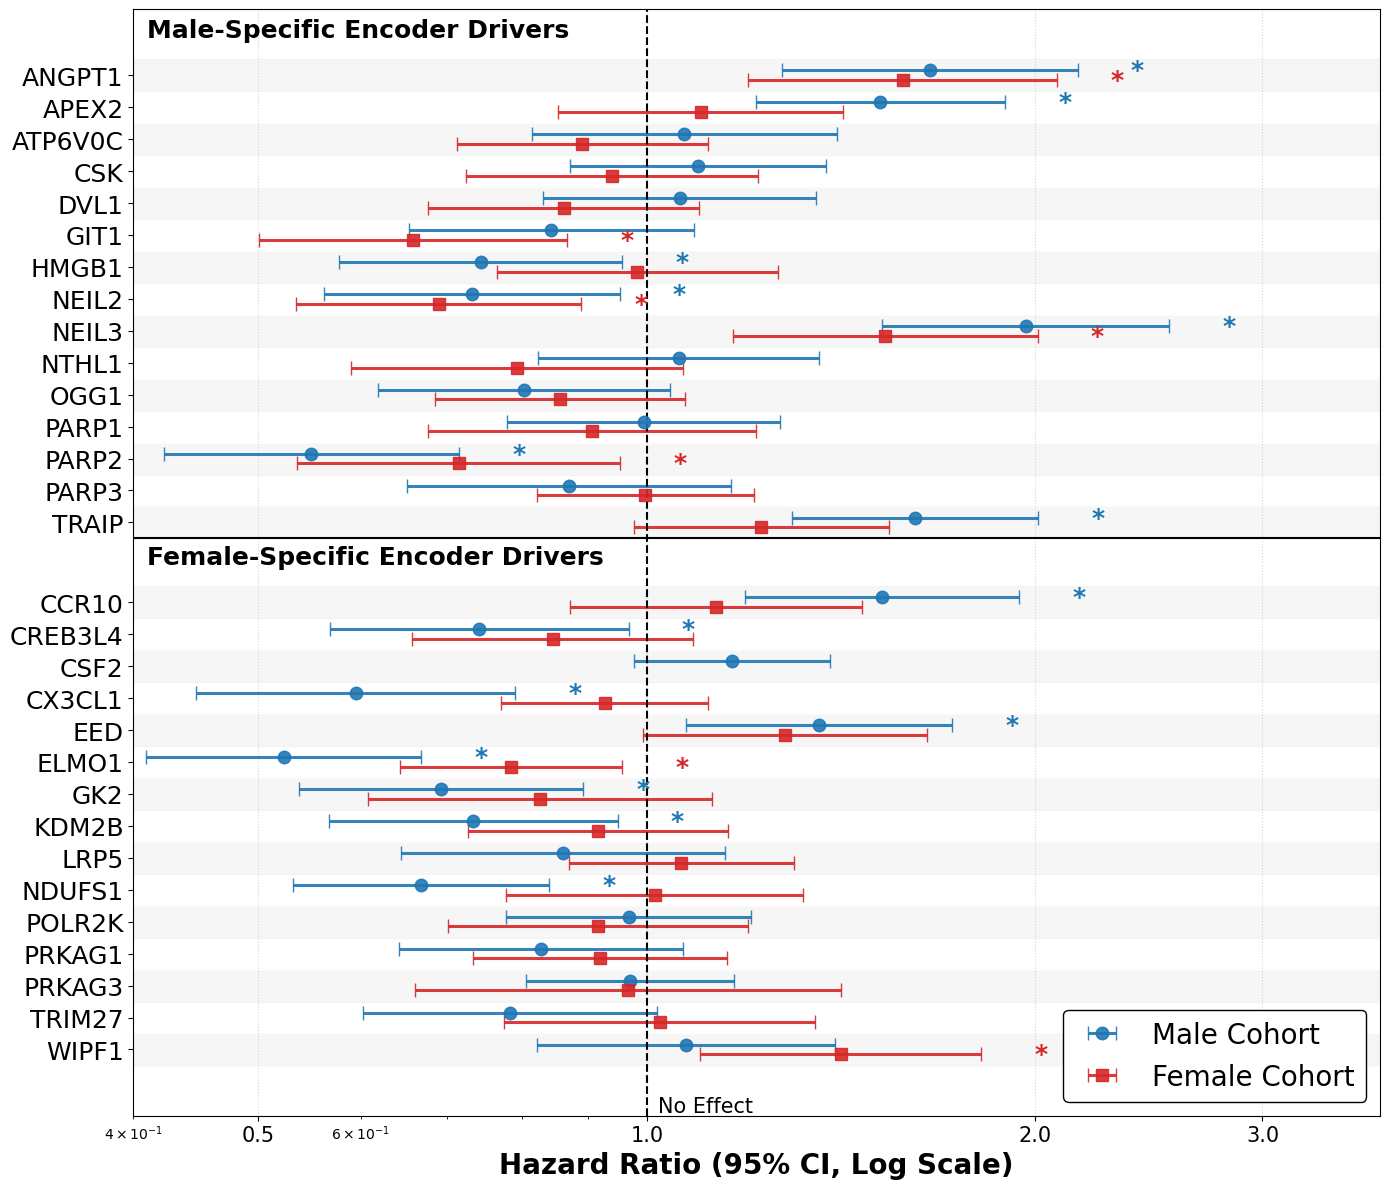

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from statsmodels.stats.multitest import multipletests

# ... [Setup & Analysis Code remains the same] ...

# =============================================================================
# 2. Visualization: Grouped Forest Plot (Compact & Optimized)
# =============================================================================

def plot_sex_stratified_forest(hr_df, male_list, female_list):
    # INCREASED WIDTH to 14 to fill horizontal space, HEIGHT adjusted to 12
    fig, ax = plt.subplots(figsize=(14, 12))
    
    groups = [("Female-Specific Encoder Drivers", sorted(female_list, reverse=True)),
              ("Male-Specific Encoder Drivers", sorted(male_list, reverse=True))]
    styles = [('Male', 0.15, '#1f77b4', 'o'), ('Female', -0.15, '#d62728', 's')]
    
    y_ticks, y_labels, current_y = [], [], 0
    
    for i, (group_name, genes) in enumerate(groups):
        # 1. Separator Line
        if i > 0:
            ax.axhline(y=current_y, color='black', linestyle='-', linewidth=1.5, alpha=1.0)
            current_y += 0.5 # REDUCED from 1.0 (Less gap after separator)
            
        # 2. Plot Genes
        for j, gene in enumerate(genes):
            # Zebra Striping
            bg_color = '#f0f0f0' if j % 2 == 0 else 'white'
            ax.axhspan(current_y - 0.5, current_y + 0.5, color=bg_color, alpha=0.6, zorder=0)

            for sex, offset, color, marker in styles:
                row = hr_df[(hr_df['Gene'] == gene) & (hr_df['Sex'] == sex)]
                if not row.empty:
                    val = row.iloc[0]
                    # Error Bar
                    ax.errorbar(val['HR'], current_y + offset, 
                                xerr=[[val['HR'] - val['CI_lower']], [val['CI_upper'] - val['HR']]],
                                fmt=marker, color=color, markersize=9, capsize=5, elinewidth=2.2, alpha=0.9,
                                label=f'{sex} cohort' if f'{sex} cohort' not in [l for l in ax.get_legend_handles_labels()[1]] else "")
                    
                    if val['P_value'] < 0.05:
                        ax.text(val['CI_upper'] * 1.1, current_y + offset, '*', 
                                color=color, va='center', ha='left', fontweight='bold', fontsize=18)

            y_ticks.append(current_y)
            y_labels.append(gene)
            current_y += 1.0 

        # 3. Add Header (Reduced padding)
        header_y = current_y + 0.2 # Moved closer to the genes
        ax.text(0.41, header_y, group_name, fontsize=18, fontweight='bold', color='black', ha='left') # Adjusted x-pos to align with tighter limit
        
        current_y += 1.0 # REDUCED from 1.5 (Less gap before next section)

    # Formatting Axes
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=18)
    
    ax.set_xscale('log')
    ax.set_xlabel('Hazard Ratio (95% CI, Log Scale)', fontsize=20, fontweight='bold')
    # ax.set_title('Prognostic Risk of Sex-Specific Genomic Drivers', fontsize=18, pad=15)
    
    # --- KEY CHANGE: TIGHTER X-LIMITS ---
    # Adjusted from [0.15, 8.0] to [0.4, 4.0] to eliminate side whitespace
    ax.set_xlim(0.4, 3.7) 
    
    # Custom Ticks for the tighter range
    ax.set_xticks([0.5, 1, 2, 3])
    ax.set_xticklabels(['0.5', '1.0', '2.0', '3.0'], fontsize=15)
    
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
    ax.text(1.02, ax.get_ylim()[0], 'No Effect', fontsize=15, color='black', va='bottom')
    
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    
    # Legend - Positioned to use empty space
    ax.legend(loc='lower right', frameon=True, fontsize=20, edgecolor='black', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    # plt.savefig(f"Plot/{cancer}_Forest_Plot_.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run visualization
plot_sex_stratified_forest(hr_results, top_male_genes, top_female_genes)

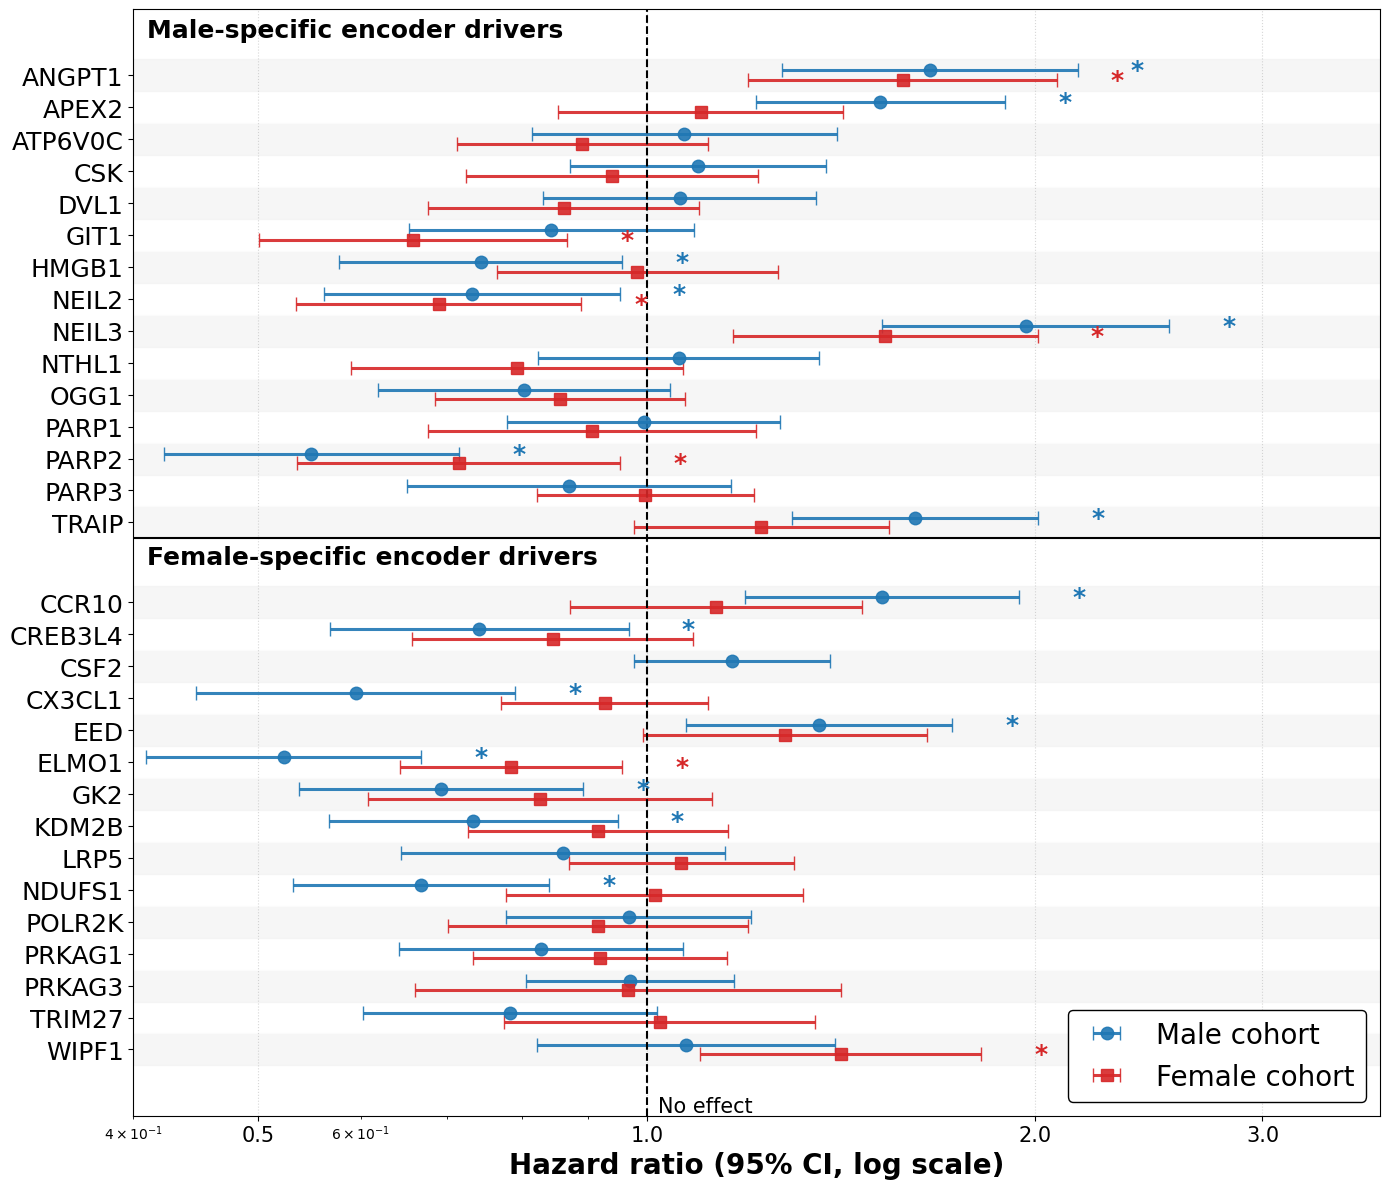

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from statsmodels.stats.multitest import multipletests

# ... [Setup & Analysis Code remains the same] ...

# =============================================================================
# 2. Visualization: Grouped Forest Plot (Compact & Optimized)
# =============================================================================

def plot_sex_stratified_forest(hr_df, male_list, female_list):
    # INCREASED WIDTH to 14 to fill horizontal space, HEIGHT adjusted to 12
    fig, ax = plt.subplots(figsize=(14, 12))
    
    groups = [("Female-specific encoder drivers", sorted(female_list, reverse=True)),
              ("Male-specific encoder drivers", sorted(male_list, reverse=True))]
    styles = [('Male', 0.15, '#1f77b4', 'o'), ('Female', -0.15, '#d62728', 's')]
    
    y_ticks, y_labels, current_y = [], [], 0
    
    for i, (group_name, genes) in enumerate(groups):
        # 1. Separator Line
        if i > 0:
            ax.axhline(y=current_y, color='black', linestyle='-', linewidth=1.5, alpha=1.0)
            current_y += 0.5 # REDUCED from 1.0 (Less gap after separator)
            
        # 2. Plot Genes
        for j, gene in enumerate(genes):
            # Zebra Striping
            bg_color = '#f0f0f0' if j % 2 == 0 else 'white'
            ax.axhspan(current_y - 0.5, current_y + 0.5, color=bg_color, alpha=0.6, zorder=0)

            for sex, offset, color, marker in styles:
                row = hr_df[(hr_df['Gene'] == gene) & (hr_df['Sex'] == sex)]
                if not row.empty:
                    val = row.iloc[0]
                    # Error Bar
                    ax.errorbar(val['HR'], current_y + offset, 
                                xerr=[[val['HR'] - val['CI_lower']], [val['CI_upper'] - val['HR']]],
                                fmt=marker, color=color, markersize=9, capsize=5, elinewidth=2.2, alpha=0.9,
                                label=f'{sex} cohort' if f'{sex} cohort' not in [l for l in ax.get_legend_handles_labels()[1]] else "")
                    
                    if val['P_value'] < 0.05:
                        ax.text(val['CI_upper'] * 1.1, current_y + offset, '*', 
                                color=color, va='center', ha='left', fontweight='bold', fontsize=18)

            y_ticks.append(current_y)
            y_labels.append(gene)
            current_y += 1.0 

        # 3. Add Header (Reduced padding)
        header_y = current_y + 0.2 # Moved closer to the genes
        ax.text(0.41, header_y, group_name, fontsize=18, fontweight='bold', color='black', ha='left') # Adjusted x-pos to align with tighter limit
        
        current_y += 1.0 # REDUCED from 1.5 (Less gap before next section)

    # Formatting Axes
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=18)
    
    ax.set_xscale('log')
    ax.set_xlabel('Hazard ratio (95% CI, log scale)', fontsize=20, fontweight='bold')
    # ax.set_title('Prognostic Risk of Sex-Specific Genomic Drivers', fontsize=18, pad=15)
    
    # --- KEY CHANGE: TIGHTER X-LIMITS ---
    # Adjusted from [0.15, 8.0] to [0.4, 4.0] to eliminate side whitespace
    ax.set_xlim(0.4, 3.7) 
    
    # Custom Ticks for the tighter range
    ax.set_xticks([0.5, 1, 2, 3])
    ax.set_xticklabels(['0.5', '1.0', '2.0', '3.0'], fontsize=15)
    
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
    ax.text(1.02, ax.get_ylim()[0], 'No effect', fontsize=15, color='black', va='bottom')
    
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    
    # Legend - Positioned to use empty space
    ax.legend(loc='lower right', frameon=True, fontsize=20, edgecolor='black', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    plt.savefig(f"Plot/Fig3_{cancer}_Forest_Plot.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run visualization
plot_sex_stratified_forest(hr_results, top_male_genes, top_female_genes)

---

In [26]:
asthma = "GSE240567"

In [27]:
asthma_data = pd.read_csv(f"/home/koe3/Bioinformatics/Data/Asthma/{asthma}/{asthma}_Normed_Entire_Data.csv")
asthma_data

,DPM1,FGR,CFH,FUCA2,GCLC,NFYA,SEMA3F,CFTR,CYP51A1,RAD52,...,H4C2,H3C10,ADORA3,PIGY,H3C2,H3C3,NPBWR1,UGT1A3,UGT1A5,Sex
0,0.413739,1.117053,0.663595,0.959307,0.817929,-1.305526,0.014267,-1.029322,0.681319,0.005165,...,0.632746,0.385485,0.409453,0.418256,0.234392,0.318593,-0.503568,-1.492085,-0.873495,1
1,0.114446,2.170677,0.461724,0.591021,-2.020163,-0.397902,0.379442,-1.548556,0.913926,-0.313306,...,0.657341,0.958368,0.442234,-0.995636,1.222865,0.997287,0.258784,-0.428357,-1.576770,0
2,1.443780,1.129986,-0.535696,-0.468586,-2.786815,-0.762972,0.207087,1.027602,0.246339,1.840001,...,0.652082,0.694510,2.407472,-3.029751,0.959210,1.049761,-0.954080,1.776278,1.877062,1
3,-1.089564,0.071863,-1.647470,-0.268176,-0.097398,0.468977,0.671395,-0.511815,0.598581,-0.606560,...,0.404252,-0.110976,0.168137,-0.480853,0.024609,-0.031836,1.188082,0.572094,1.050699,0
4,0.358323,0.261149,0.664754,0.691456,-0.006163,-1.421467,0.422877,-0.179158,0.647699,-1.462079,...,-0.351118,0.102787,-0.446755,-0.083824,-0.357480,0.060902,-0.193603,0.347017,0.117870,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,-0.393063,0.563204,0.640517,1.364692,0.085180,-0.640820,0.066068,-1.513612,0.244345,-0.472774,...,0.333290,1.039323,0.406330,0.325758,1.597732,1.277206,-1.550051,-0.670255,-0.164198,0
532,0.084791,-0.307321,0.444163,-0.477689,0.647847,0.052377,0.197531,0.242334,0.533503,-1.280742,...,0.468889,0.463161,0.031190,1.450512,0.592012,0.678726,0.542118,-0.797493,-0.964889,0
533,1.185496,0.213295,0.928651,0.394510,1.295366,0.210903,-0.265704,-0.614320,-0.120929,-0.636251,...,0.138450,0.055977,-0.414633,1.724079,0.336815,0.412270,-0.193252,-0.467288,0.253874,1
534,0.230130,0.519622,0.341761,0.525099,0.611224,0.274294,0.092080,-0.153758,0.595299,-0.513446,...,0.559750,0.697311,0.089098,0.919559,0.859773,0.803443,-0.866965,-1.112102,-0.976648,0


In [28]:
asthma_data['Sex'] = asthma_data['Sex'].apply(lambda x: 'Male' if x == 1 else 'Female')
asthma_data

,DPM1,FGR,CFH,FUCA2,GCLC,NFYA,SEMA3F,CFTR,CYP51A1,RAD52,...,H4C2,H3C10,ADORA3,PIGY,H3C2,H3C3,NPBWR1,UGT1A3,UGT1A5,Sex
0,0.413739,1.117053,0.663595,0.959307,0.817929,-1.305526,0.014267,-1.029322,0.681319,0.005165,...,0.632746,0.385485,0.409453,0.418256,0.234392,0.318593,-0.503568,-1.492085,-0.873495,Male
1,0.114446,2.170677,0.461724,0.591021,-2.020163,-0.397902,0.379442,-1.548556,0.913926,-0.313306,...,0.657341,0.958368,0.442234,-0.995636,1.222865,0.997287,0.258784,-0.428357,-1.576770,Female
2,1.443780,1.129986,-0.535696,-0.468586,-2.786815,-0.762972,0.207087,1.027602,0.246339,1.840001,...,0.652082,0.694510,2.407472,-3.029751,0.959210,1.049761,-0.954080,1.776278,1.877062,Male
3,-1.089564,0.071863,-1.647470,-0.268176,-0.097398,0.468977,0.671395,-0.511815,0.598581,-0.606560,...,0.404252,-0.110976,0.168137,-0.480853,0.024609,-0.031836,1.188082,0.572094,1.050699,Female
4,0.358323,0.261149,0.664754,0.691456,-0.006163,-1.421467,0.422877,-0.179158,0.647699,-1.462079,...,-0.351118,0.102787,-0.446755,-0.083824,-0.357480,0.060902,-0.193603,0.347017,0.117870,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,-0.393063,0.563204,0.640517,1.364692,0.085180,-0.640820,0.066068,-1.513612,0.244345,-0.472774,...,0.333290,1.039323,0.406330,0.325758,1.597732,1.277206,-1.550051,-0.670255,-0.164198,Female
532,0.084791,-0.307321,0.444163,-0.477689,0.647847,0.052377,0.197531,0.242334,0.533503,-1.280742,...,0.468889,0.463161,0.031190,1.450512,0.592012,0.678726,0.542118,-0.797493,-0.964889,Female
533,1.185496,0.213295,0.928651,0.394510,1.295366,0.210903,-0.265704,-0.614320,-0.120929,-0.636251,...,0.138450,0.055977,-0.414633,1.724079,0.336815,0.412270,-0.193252,-0.467288,0.253874,Male
534,0.230130,0.519622,0.341761,0.525099,0.611224,0.274294,0.092080,-0.153758,0.595299,-0.513446,...,0.559750,0.697311,0.089098,0.919559,0.859773,0.803443,-0.866965,-1.112102,-0.976648,Female


In [29]:
label = pd.read_csv(f"/home/koe3/Bioinformatics/Data/Asthma/{asthma}/{asthma}_Entire_Label.csv")
label

,Label
0,1
1,1
2,1
3,1
4,1
...,...
531,0
532,0
533,0
534,0


In [30]:
asthma_df = pd.concat([asthma_data, label], axis=1)
asthma_df

,DPM1,FGR,CFH,FUCA2,GCLC,NFYA,SEMA3F,CFTR,CYP51A1,RAD52,...,H3C10,ADORA3,PIGY,H3C2,H3C3,NPBWR1,UGT1A3,UGT1A5,Sex,Label
0,0.413739,1.117053,0.663595,0.959307,0.817929,-1.305526,0.014267,-1.029322,0.681319,0.005165,...,0.385485,0.409453,0.418256,0.234392,0.318593,-0.503568,-1.492085,-0.873495,Male,1
1,0.114446,2.170677,0.461724,0.591021,-2.020163,-0.397902,0.379442,-1.548556,0.913926,-0.313306,...,0.958368,0.442234,-0.995636,1.222865,0.997287,0.258784,-0.428357,-1.576770,Female,1
2,1.443780,1.129986,-0.535696,-0.468586,-2.786815,-0.762972,0.207087,1.027602,0.246339,1.840001,...,0.694510,2.407472,-3.029751,0.959210,1.049761,-0.954080,1.776278,1.877062,Male,1
3,-1.089564,0.071863,-1.647470,-0.268176,-0.097398,0.468977,0.671395,-0.511815,0.598581,-0.606560,...,-0.110976,0.168137,-0.480853,0.024609,-0.031836,1.188082,0.572094,1.050699,Female,1
4,0.358323,0.261149,0.664754,0.691456,-0.006163,-1.421467,0.422877,-0.179158,0.647699,-1.462079,...,0.102787,-0.446755,-0.083824,-0.357480,0.060902,-0.193603,0.347017,0.117870,Male,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,-0.393063,0.563204,0.640517,1.364692,0.085180,-0.640820,0.066068,-1.513612,0.244345,-0.472774,...,1.039323,0.406330,0.325758,1.597732,1.277206,-1.550051,-0.670255,-0.164198,Female,0
532,0.084791,-0.307321,0.444163,-0.477689,0.647847,0.052377,0.197531,0.242334,0.533503,-1.280742,...,0.463161,0.031190,1.450512,0.592012,0.678726,0.542118,-0.797493,-0.964889,Female,0
533,1.185496,0.213295,0.928651,0.394510,1.295366,0.210903,-0.265704,-0.614320,-0.120929,-0.636251,...,0.055977,-0.414633,1.724079,0.336815,0.412270,-0.193252,-0.467288,0.253874,Male,0
534,0.230130,0.519622,0.341761,0.525099,0.611224,0.274294,0.092080,-0.153758,0.595299,-0.513446,...,0.697311,0.089098,0.919559,0.859773,0.803443,-0.866965,-1.112102,-0.976648,Female,0


In [31]:
asthma_df = asthma_df.rename(columns={'Label': 'Asthma_Status'})
asthma_df

,DPM1,FGR,CFH,FUCA2,GCLC,NFYA,SEMA3F,CFTR,CYP51A1,RAD52,...,H3C10,ADORA3,PIGY,H3C2,H3C3,NPBWR1,UGT1A3,UGT1A5,Sex,Asthma_Status
0,0.413739,1.117053,0.663595,0.959307,0.817929,-1.305526,0.014267,-1.029322,0.681319,0.005165,...,0.385485,0.409453,0.418256,0.234392,0.318593,-0.503568,-1.492085,-0.873495,Male,1
1,0.114446,2.170677,0.461724,0.591021,-2.020163,-0.397902,0.379442,-1.548556,0.913926,-0.313306,...,0.958368,0.442234,-0.995636,1.222865,0.997287,0.258784,-0.428357,-1.576770,Female,1
2,1.443780,1.129986,-0.535696,-0.468586,-2.786815,-0.762972,0.207087,1.027602,0.246339,1.840001,...,0.694510,2.407472,-3.029751,0.959210,1.049761,-0.954080,1.776278,1.877062,Male,1
3,-1.089564,0.071863,-1.647470,-0.268176,-0.097398,0.468977,0.671395,-0.511815,0.598581,-0.606560,...,-0.110976,0.168137,-0.480853,0.024609,-0.031836,1.188082,0.572094,1.050699,Female,1
4,0.358323,0.261149,0.664754,0.691456,-0.006163,-1.421467,0.422877,-0.179158,0.647699,-1.462079,...,0.102787,-0.446755,-0.083824,-0.357480,0.060902,-0.193603,0.347017,0.117870,Male,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,-0.393063,0.563204,0.640517,1.364692,0.085180,-0.640820,0.066068,-1.513612,0.244345,-0.472774,...,1.039323,0.406330,0.325758,1.597732,1.277206,-1.550051,-0.670255,-0.164198,Female,0
532,0.084791,-0.307321,0.444163,-0.477689,0.647847,0.052377,0.197531,0.242334,0.533503,-1.280742,...,0.463161,0.031190,1.450512,0.592012,0.678726,0.542118,-0.797493,-0.964889,Female,0
533,1.185496,0.213295,0.928651,0.394510,1.295366,0.210903,-0.265704,-0.614320,-0.120929,-0.636251,...,0.055977,-0.414633,1.724079,0.336815,0.412270,-0.193252,-0.467288,0.253874,Male,0
534,0.230130,0.519622,0.341761,0.525099,0.611224,0.274294,0.092080,-0.153758,0.595299,-0.513446,...,0.697311,0.089098,0.919559,0.859773,0.803443,-0.866965,-1.112102,-0.976648,Female,0


In [92]:
top_common_genes = ['IGF1', 'NCK2', 'TNFRSF1A', 'IRS1', 'PCK2', 'UGT1A8', 'PRKAA1',
       'ESPL1', 'PIK3CG', 'SHC2', 'MGST1', 'CREB3L1', 'BIRC3', 'POLA1',
       'IRAK1']

In [32]:
top_male_genes = ['WNT9A', 'HSPA1A', 'DCTN3', 'PLA2G4B', 'DMD', 'MECOM', 'CREB3',
       'PTCH1', 'PINK1', 'SMO', 'ITGA7', 'MTOR', 'HSPA8', 'GSTM3',
       'NDUFB1']

In [33]:
top_female_genes = ['PIK3CA', 'LPL', 'PIK3CD', 'CDK5', 'IRAK1', 'PIK3CB', 'SMAD3',
       'CRKL', 'CDC45', 'TRAF6', 'FAS', 'PDGFB', 'CDKN1A', 'TUBB8',
       'CXCR4']

In [34]:
all_genes_to_analyze = list(set(top_male_genes + top_female_genes))

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

print("\n--- Formal Interaction Testing: Asthma Susceptibility ---")

# Assuming asthma_df and all_genes_to_analyze are already defined

interaction_results = []

# 1. Create a numeric Sex column for the entire dataset (e.g., Male=1, Female=0)
asthma_df['Sex_Num'] = asthma_df['Sex'].map({'Male': 1, 'Female': 0})

for gene in all_genes_to_analyze:
    if gene not in asthma_df.columns: continue
    
    # 2. Extract unified data and drop NaNs
    subset = asthma_df[['Asthma_Status', gene, 'Sex_Num']].dropna()
    if subset.empty: continue
        
    # 3. Create the Interaction Term (Gene expression * Numeric Sex)
    subset['Gene_x_Sex'] = subset[gene] * subset['Sex_Num']
    
    # 4. Define independent variables (Main effects + Interaction)
    X = subset[[gene, 'Sex_Num', 'Gene_x_Sex']]
    y = subset['Asthma_Status']
    
    # Add constant for intercept
    X = sm.add_constant(X)
    
    try:
        # 5. Fit unified Logistic Regression
        model = sm.Logit(y, X)
        result = model.fit(disp=0)
        
        # 6. We specifically care about the INTERACTION term's p-value
        interaction_pval = result.pvalues['Gene_x_Sex']
        interaction_coef = result.params['Gene_x_Sex']
        
        interaction_results.append({
            'Gene': gene,
            'Interaction_Coef': interaction_coef,
            'Interaction_P_value': interaction_pval
        })
    except Exception as e:
        pass

interaction_df = pd.DataFrame(interaction_results)

# Apply FDR Correction to the interaction p-values
if not interaction_df.empty:
    interaction_df['Interaction_FDR'] = multipletests(
        interaction_df['Interaction_P_value'], alpha=0.01, method='fdr_bh'
    )[1]

print(interaction_df.sort_values('Interaction_P_value').head())


--- Formal Interaction Testing: Asthma Susceptibility ---
      Gene  Interaction_Coef  Interaction_P_value  Interaction_FDR
8   PIK3CD          0.367056             0.037323          0.82305
18   TUBB8         -0.307189             0.099510          0.82305
13    MTOR          0.263568             0.140863          0.82305
16     LPL         -0.255557             0.159143          0.82305
28  CDKN1A          0.216171             0.227796          0.82305


In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# =============================================================================
# 0. Setup & Data Preparation
# =============================================================================
print("\n--- Starting Analysis: Asthma Risk Quantification (Odds Ratios) ---")

# Placeholder lists for Asthma-specific genes
# Replace these with your actual identified drivers
top_male_genes = ['WNT9A', 'HSPA1A', 'DCTN3', 'PLA2G4B', 'DMD', 'MECOM', 'CREB3',
       'PTCH1', 'PINK1', 'SMO', 'ITGA7', 'MTOR', 'HSPA8', 'GSTM3',
       'NDUFB1']

top_female_genes = ['PIK3CA', 'LPL', 'PIK3CD', 'CDK5', 'IRAK1', 'PIK3CB', 'SMAD3',
       'CRKL', 'CDC45', 'TRAF6', 'FAS', 'PDGFB', 'CDKN1A', 'TUBB8',
       'CXCR4']

all_genes_to_analyze = list(set(top_male_genes + top_female_genes))
results_list = []

# =============================================================================
# 1. Statistical Analysis (Logistic Regression)
# =============================================================================
# Assumption: 'data' dataframe exists.
# Assumption: 'Asthma_Status' is the binary target column (1 = Asthma, 0 = Control)
# If your column has a different name, change 'Asthma_Status' below.

# Example dummy data generation (Uncomment if testing without real data)
# data = pd.DataFrame({
#     'Sex': np.random.choice(['Male', 'Female'], 500),
#     'Asthma_Status': np.random.randint(0, 2, 500),
#     **{gene: np.random.normal(0, 1, 500) for gene in all_genes_to_analyze}
# })

for sex in ['Male', 'Female']:
    # Filter data for the current sex
    data_sex = asthma_df[asthma_df['Sex'] == sex].copy()
    
    for gene in all_genes_to_analyze:
        if gene not in data_sex.columns: continue

        # Prepare data for Logistic Regression
        # Drop NaNs in target or gene
        subset = data_sex[['Asthma_Status', gene]].dropna()
        
        if subset.empty: continue

        X = subset[[gene]]
        y = subset['Asthma_Status']
        
        # Add constant for the intercept
        X = sm.add_constant(X)
        
        try:
            # Fit Logistic Regression
            model = sm.Logit(y, X)
            result = model.fit(disp=0) # disp=0 suppresses convergence messages
            
            # Extract Odds Ratio (OR) = exp(coefficient)
            coef = result.params[gene]
            conf_int = result.conf_int().loc[gene]
            
            or_val = np.exp(coef)
            ci_lower = np.exp(conf_int[0])
            ci_upper = np.exp(conf_int[1])
            p_val = result.pvalues[gene]
            
            results_list.append({
                'Sex': sex,
                'Gene': gene,
                'OR': or_val,          # Changed from HR to OR
                'CI_lower': ci_lower,
                'CI_upper': ci_upper,
                'P_value': p_val
            })
        except Exception as e:
            # print(f"Skipping {gene} for {sex}: {e}") 
            pass

or_results = pd.DataFrame(results_list)

# Apply FDR Correction (Benjamini-Hochberg) within each sex
if not or_results.empty:
    or_results['FDR'] = or_results.groupby('Sex')['P_value'].transform(
        lambda x: multipletests(x, alpha=0.01, method='fdr_bh')[1]
    )

print("\nSex-Stratified Odds Ratios (Top 5 Rows):")
print(or_results.head())


--- Starting Analysis: Asthma Risk Quantification (Odds Ratios) ---

Sex-Stratified Odds Ratios (Top 5 Rows):
    Sex   Gene        OR  CI_lower  CI_upper   P_value       FDR
0  Male  CXCR4  0.813289  0.628451  1.052490  0.116167  0.387225
1  Male  GSTM3  0.909944  0.679479  1.218576  0.526520  0.945532
2  Male   CDK5  0.977475  0.749020  1.275609  0.866787  0.945532
3  Male  CREB3  1.036245  0.796969  1.347360  0.790397  0.945532
4  Male   MTOR  0.908285  0.703995  1.171857  0.459299  0.945532


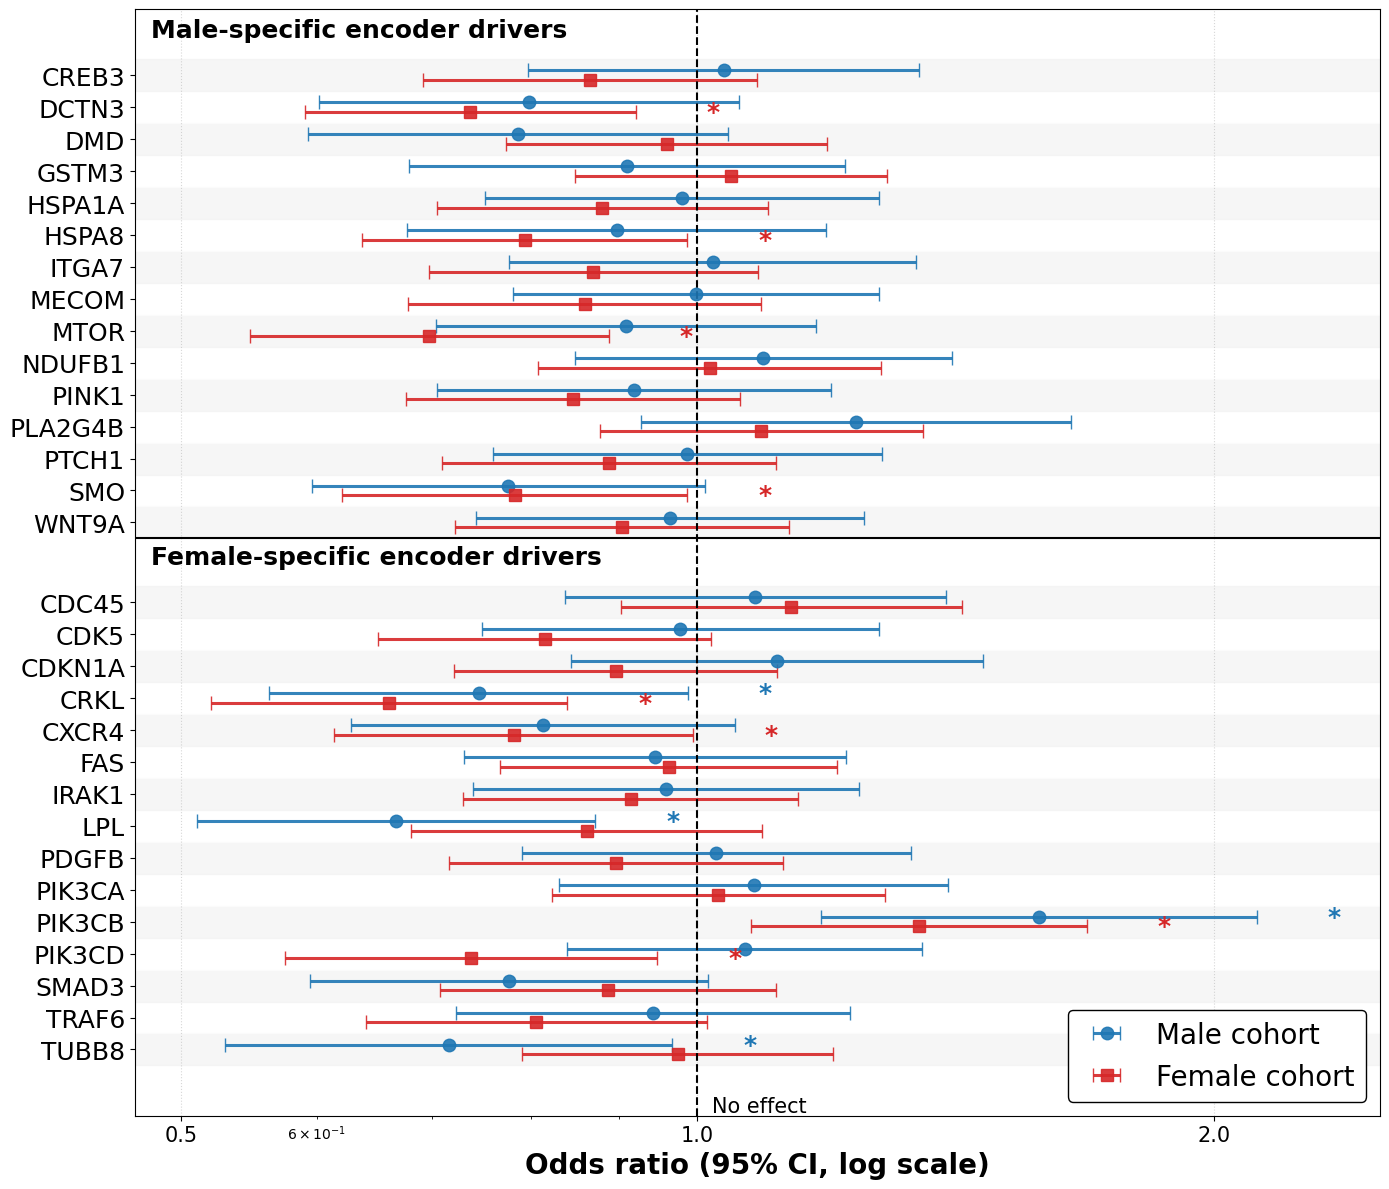

In [170]:
# =============================================================================
# 2. Visualization: Grouped Forest Plot (Logistic Regression Version)
# =============================================================================
def plot_sex_stratified_forest(or_df, male_list, female_list):
    # INCREASED WIDTH to 14 to fill horizontal space, HEIGHT adjusted to 12
    fig, ax = plt.subplots(figsize=(14, 12))
    
    groups = [("Female-specific encoder drivers", sorted(female_list, reverse=True)),
              ("Male-specific encoder drivers", sorted(male_list, reverse=True))]
    styles = [('Male', 0.15, '#1f77b4', 'o'), ('Female', -0.15, '#d62728', 's')]
    
    y_ticks, y_labels, current_y = [], [], 0
    
    for i, (group_name, genes) in enumerate(groups):
        # 1. Separator Line
        if i > 0:
            ax.axhline(y=current_y, color='black', linestyle='-', linewidth=1.5, alpha=1.0)
            current_y += 0.5 # REDUCED from 1.0 (Less gap after separator)
            
        # 2. Plot Genes
        for j, gene in enumerate(genes):
            # Zebra Striping
            bg_color = '#f0f0f0' if j % 2 == 0 else 'white'
            ax.axhspan(current_y - 0.5, current_y + 0.5, color=bg_color, alpha=0.6, zorder=0)

            for sex, offset, color, marker in styles:
                row = or_df[(or_df['Gene'] == gene) & (or_df['Sex'] == sex)]
                if not row.empty:
                    val = row.iloc[0]
                    # Error Bar
                    ax.errorbar(val['OR'], current_y + offset, 
                                xerr=[[val['OR'] - val['CI_lower']], [val['CI_upper'] - val['OR']]],
                                fmt=marker, color=color, markersize=9, capsize=5, elinewidth=2.2, alpha=0.9,
                                label=f'{sex} cohort' if f'{sex} cohort' not in [l for l in ax.get_legend_handles_labels()[1]] else "")
                    
                    if val['P_value'] < 0.05:
                        ax.text(val['CI_upper'] * 1.1, current_y + offset, '*', 
                                color=color, va='center', ha='left', fontweight='bold', fontsize=18)

            y_ticks.append(current_y)
            y_labels.append(gene)
            current_y += 1.0 

        # 3. Add Header (Reduced padding)
        header_y = current_y + 0.2 # Moved closer to the genes
        ax.text(0.48, header_y, group_name, fontsize=18, fontweight='bold', color='black', ha='left') # Adjusted x-pos to align with tighter limit
        
        current_y += 1.0 # REDUCED from 1.5 (Less gap before next section)

    # Formatting Axes
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=18)
    
    ax.set_xscale('log')
    # ax.set_xlabel('Hazard Ratio (95% CI, Log Scale)', fontsize=20, fontweight='bold')
    ax.set_xlabel('Odds ratio (95% CI, log scale)', fontsize=20, fontweight='bold')
    # ax.set_title('Prognostic Risk of Sex-Specific Genomic Drivers', fontsize=18, pad=15)
    
    # --- KEY CHANGE: TIGHTER X-LIMITS ---
    # Adjusted from [0.15, 8.0] to [0.4, 4.0] to eliminate side whitespace
    ax.set_xlim(0.47, 2.5) 
    
    # Custom Ticks for the tighter range
    ax.set_xticks([0.5, 1, 2])
    ax.set_xticklabels(['0.5', '1.0', '2.0'], fontsize=15)
    
    ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
    ax.text(1.02, ax.get_ylim()[0], 'No effect', fontsize=15, color='black', va='bottom')
    
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    
    # Legend - Positioned to use empty space
    ax.legend(loc='lower right', frameon=True, fontsize=20, edgecolor='black', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    plt.savefig(f"Plot/Fig3_{asthma}_Forest_Plot_.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run visualization
plot_sex_stratified_forest(or_results, top_male_genes, top_female_genes)

---

---

In [ ]:
pathways_to_analyze = list(top_male_pathways[:5] + top_female_pathways[:5])

In [ ]:
pathways_to_analyze

['KEGG_MEDICUS_VARIANT_MUTATION_CAUSED_ABERRANT_ABETA_TO_ELECTRON_TRANSFER_IN_COMPLEX_IV',
 'KEGG_MEDICUS_REFERENCE_TRAIP_DEPENDENT_REPLISOME_DISASSEMBLY',
 'KEGG_BASE_EXCISION_REPAIR',
 'KEGG_MEDICUS_REFERENCE_GF_RTK_PI3K_SIGNALING_PATHWAY',
 'KEGG_MEDICUS_REFERENCE_TIGHT_JUNCTION_ACTIN_SIGNALING_PATHWAY',
 'KEGG_MEDICUS_PATHOGEN_ESCHERICHIA_EAE_TIR_TO_ACTIN_SIGNALING_PATHWAY',
 'KEGG_MEDICUS_REFERENCE_CX3CR1_GNAI_AC_PKA_SIGNALING_PATHWAY',
 'KEGG_MEDICUS_REFERENCE_ACTIVATION_OF_PRC2.2_BY_UBIQUITINATION_OF_H2AK119',
 'KEGG_MEDICUS_PATHOGEN_HIV_TAT_TO_TLR2_4_NFKB_SIGNALING_PATHWAY',
 'KEGG_MEDICUS_VARIANT_FZD7_OVEREXPRESSION_TO_WNT_SIGNALING_PATHWAY']

In [ ]:
# Check correlation between Risk Score and Time
correlation = male_pathway_df['Risk_Score'].corr(male_pathway_df['T'])
print(f"Correlation: {correlation}")

Correlation: 0.6143404049011295


In [ ]:
# Check correlation between Risk Score and Time
correlation = female_pathway_df['Risk_Score'].corr(female_pathway_df['T'])
print(f"Correlation: {correlation}")

Correlation: 0.5103418684473574



--- Starting Individual Plot Analysis with Confidence Intervals ---


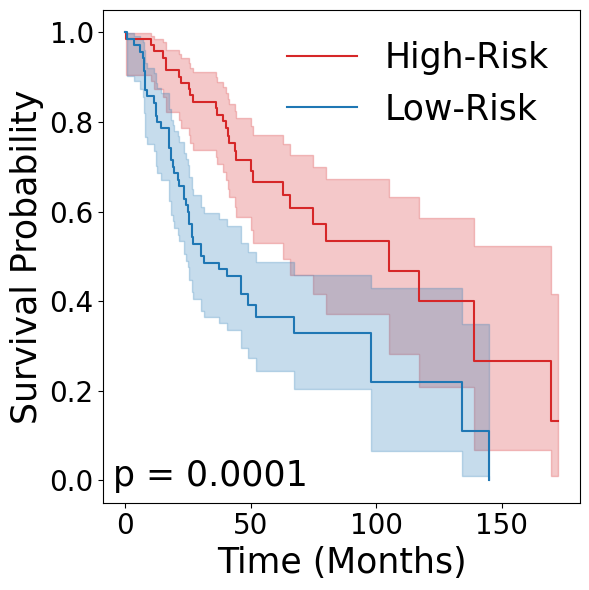

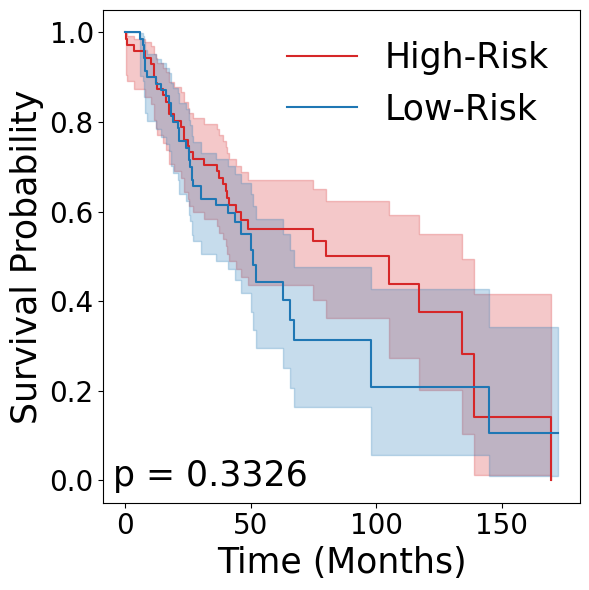

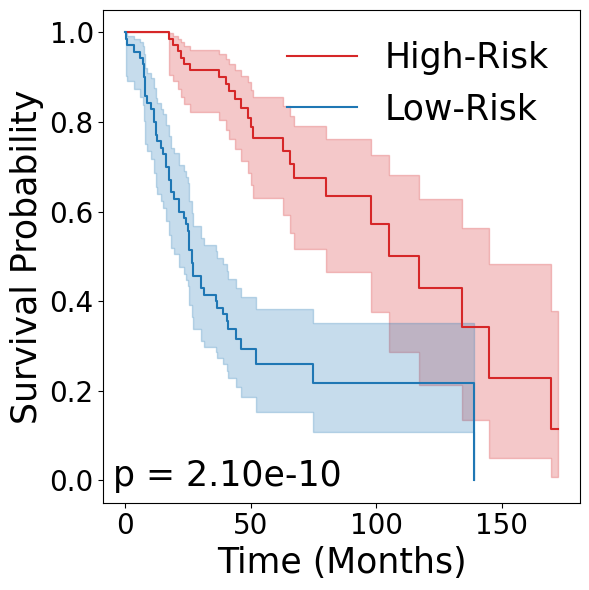

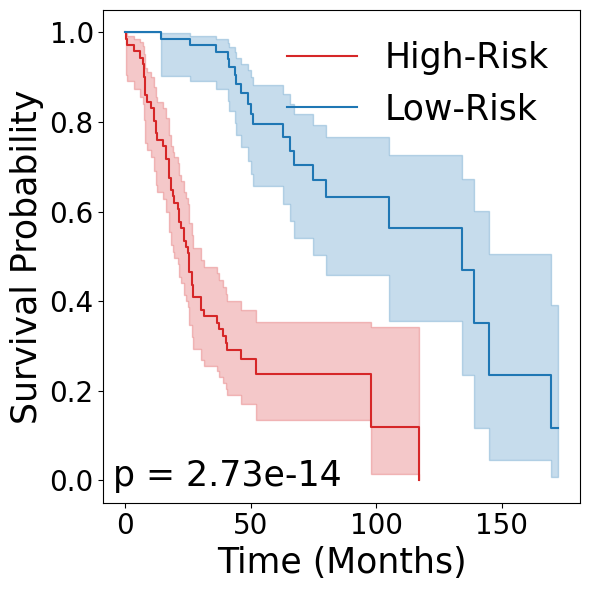

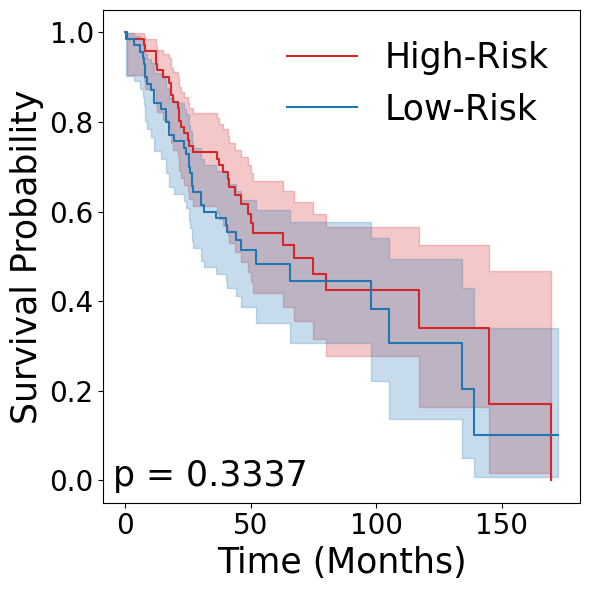

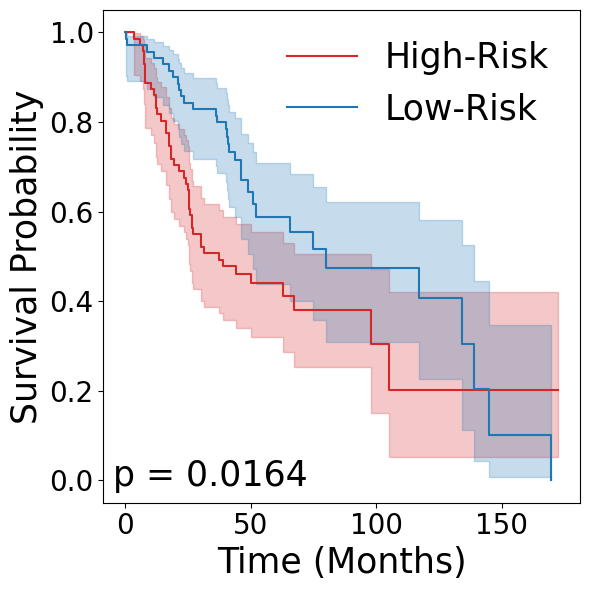

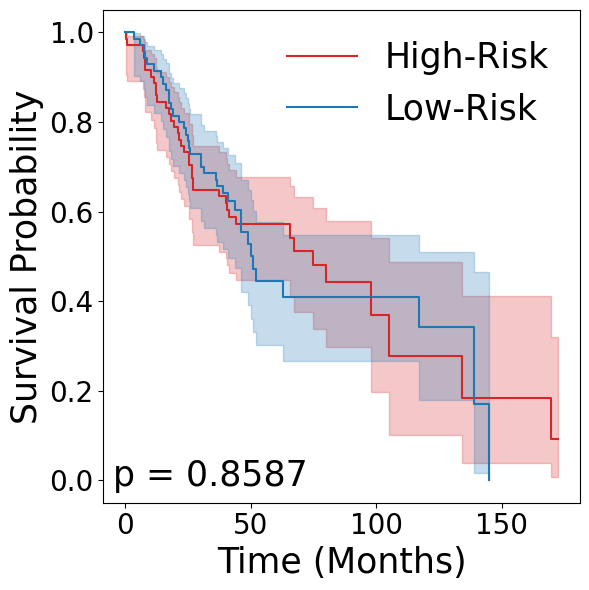

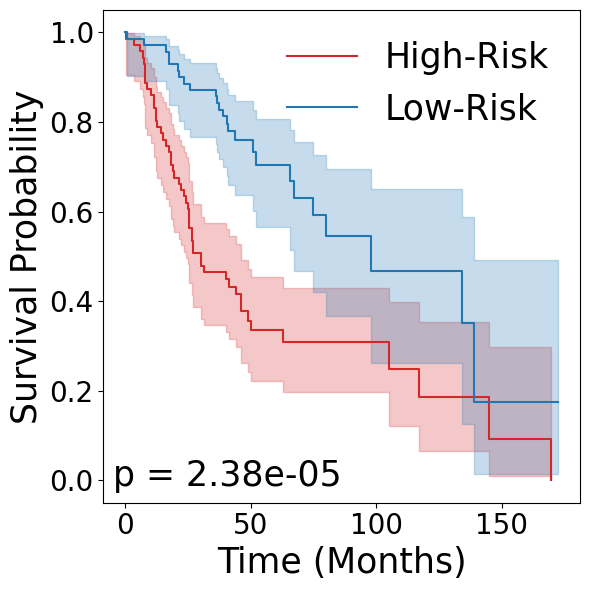

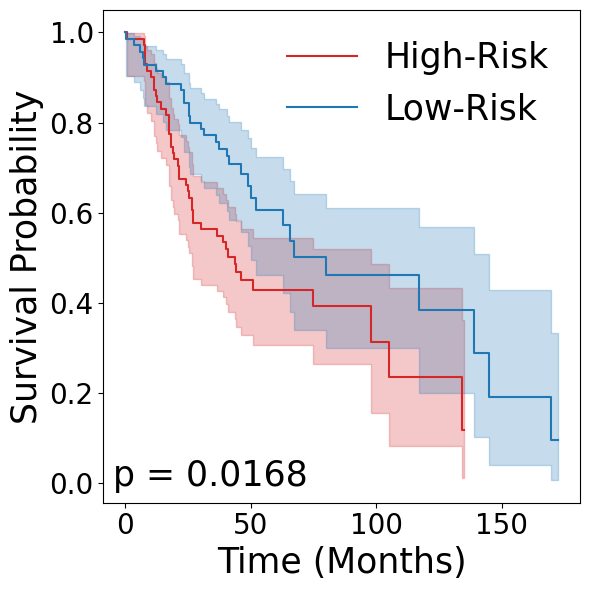

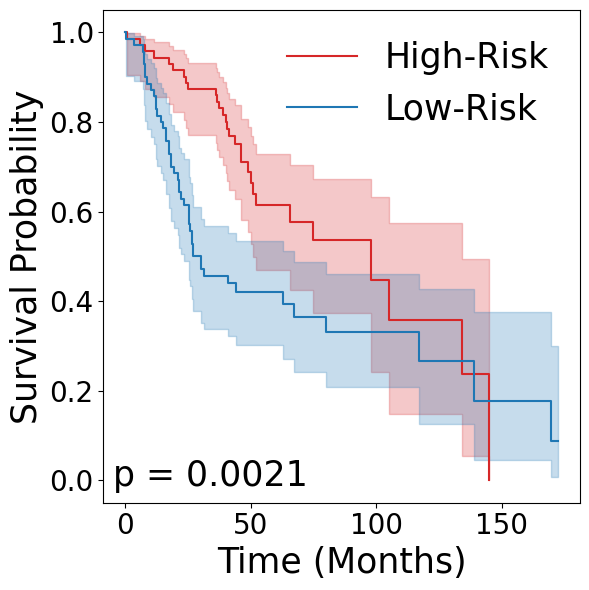

In [198]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import string 

# --- Configuration ---
# Updated colors to match the figure (Orange & Blue)
# color_high = '#ff7f0e' # Orange (Standard Matplotlib 'C1')
# color_low = '#1f77b4'  # Blue   (Standard Matplotlib 'C0')
color_high = '#D62728' # Red
color_low = '#1F77B4'  # Blue
# color_high = '#ff7f0e' # Standard Matplotlib Orange
# color_low  = '#1f77b4' # Standard Matplotlib Blue

kmf = KaplanMeierFitter()

print("\n--- Starting Individual Plot Analysis with Confidence Intervals ---")

# Iterate directly through the list of pathways
for i, pathway in enumerate(pathways_to_analyze):
    
    # 1. Initialize a NEW Figure for every pathway
    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca() 
    
    # --- 2. Data Prep ---
    median_score = male_pathway_df[pathway].median()
    plot_df = male_pathway_df.copy()
    
    plot_df['Current_Risk'] = plot_df[pathway].apply(
        lambda x: 'Low-Risk' if x > median_score else 'High-Risk'
    )
    
    T = plot_df['T']
    E = plot_df['E']
    ix_high = (plot_df['Current_Risk'] == 'High-Risk')
    ix_low = (plot_df['Current_Risk'] == 'Low-Risk')

    # --- 3. Plotting with VARIATION (Confidence Intervals) ---
    # Plot Low-Risk
    # kmf.fit(T[ix_low], E[ix_low], label='Low-Risk')
    # kmf.plot_survival_function(ax=ax)
    # Plot High-Risk (Orange)
    kmf.fit(T[ix_high], E[ix_high], label='High-Risk') # Updated label to match figure style
    kmf.plot_survival_function(ax=ax, color=color_high)
    
    # Plot Low-Risk (Blue)
    kmf.fit(T[ix_low], E[ix_low], label='Low-Risk')    # Updated label to match figure style
    kmf.plot_survival_function(ax=ax, color=color_low)

    # --- 4. Conditional P-Value Formatting ---
    results = logrank_test(T[ix_high], T[ix_low], E[ix_high], E[ix_low])
    p_val = results.p_value
    
    if p_val < 0.0001:
        p_text = f"p = {p_val:.2e}" 
    else:
        p_text = f"p = {p_val:.4f}" 

    ax.text(0.02, 0.02, p_text, 
            transform=ax.transAxes, 
            fontsize=25, 
            # fontweight='bold', 
            verticalalignment='bottom')

    # --- 5. Styling ---
    # Set the title to the pathway name
    # clean_title = pathway.replace('_', ' ') 
    # ax.set_title(clean_title, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    ax.set_xlabel('Time (Months)', fontsize=25)
    ax.set_ylabel('Survival Probability', fontsize=25)
    ax.legend(frameon=False, loc='upper right', fontsize=25)
    ax.grid(False)

    plt.tight_layout()
    
    # --- 6. Save or Show ---
    clean_name = pathway.replace("/", "_").replace(" ", "_")
    
    plt.savefig(f"Plot/{clean_name}_KM_Curve_byMale.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

---


--- Starting Individual Plot Analysis ---


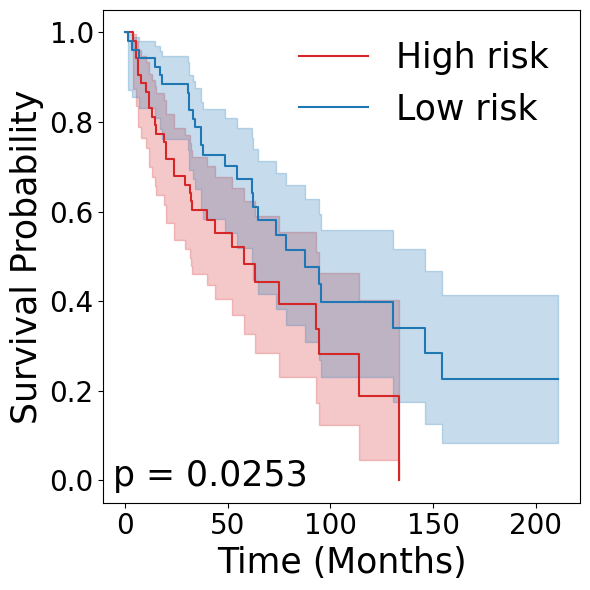

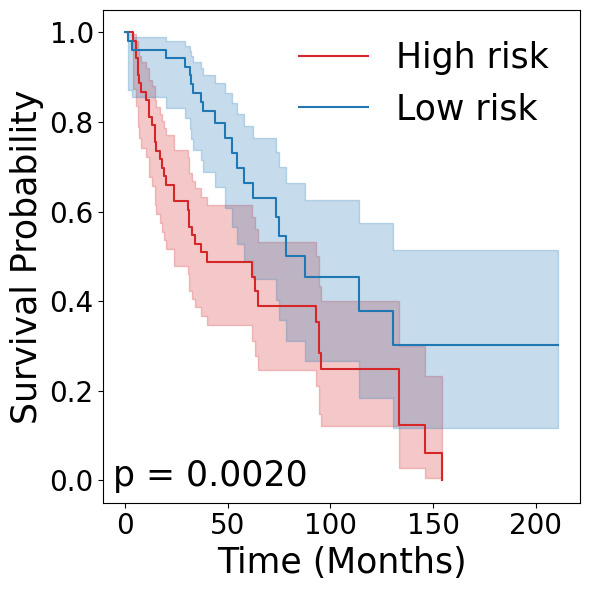

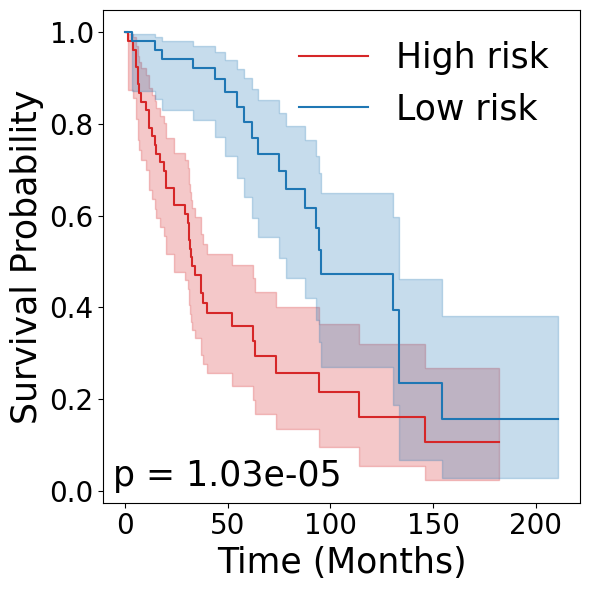

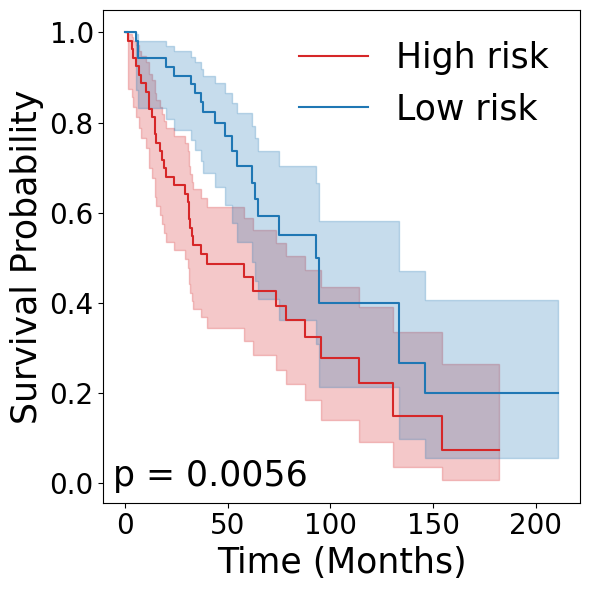

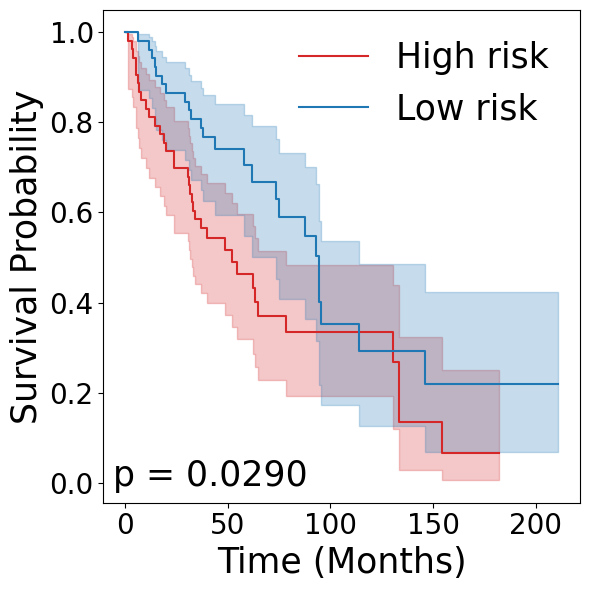

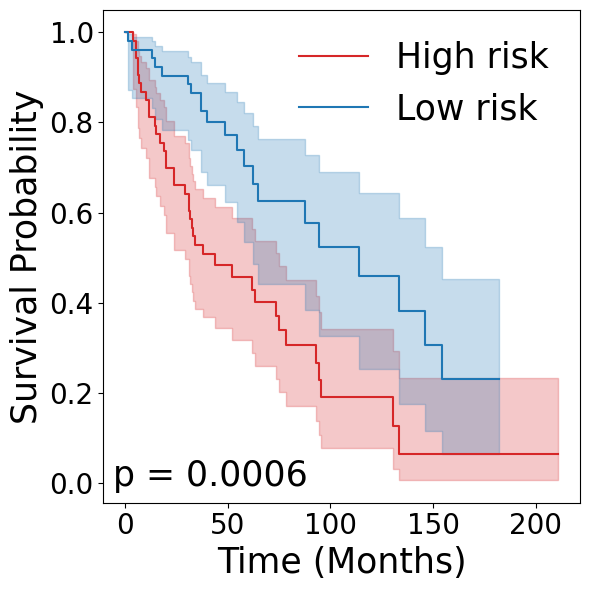

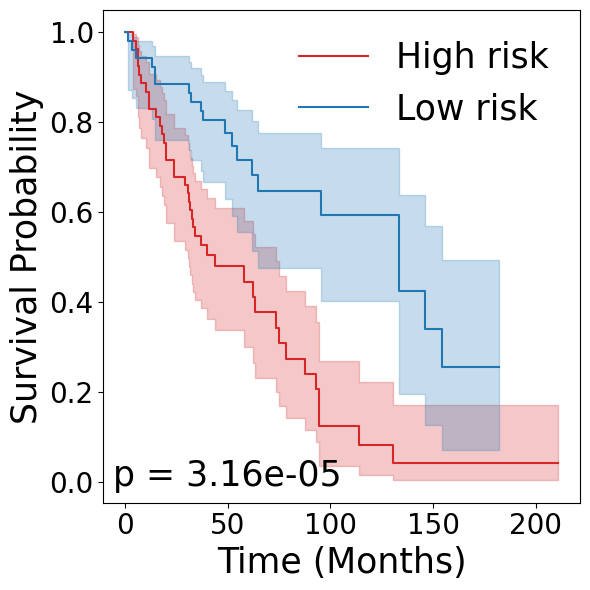

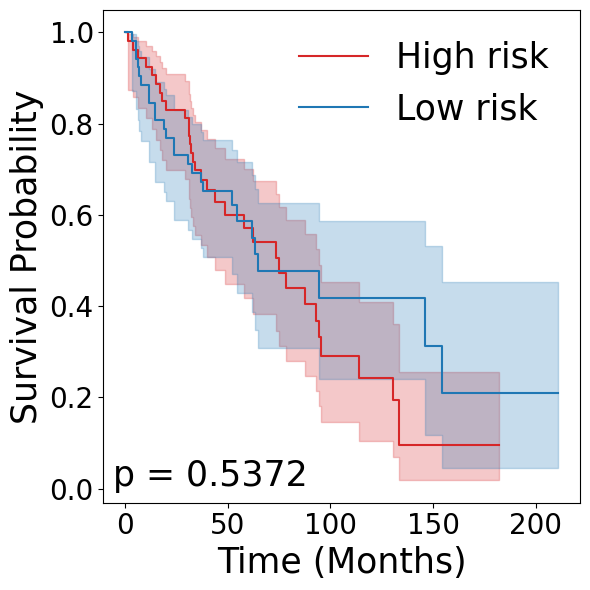

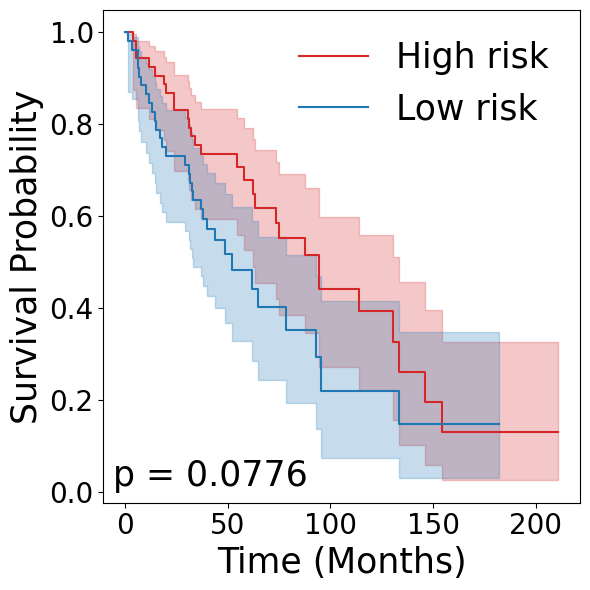

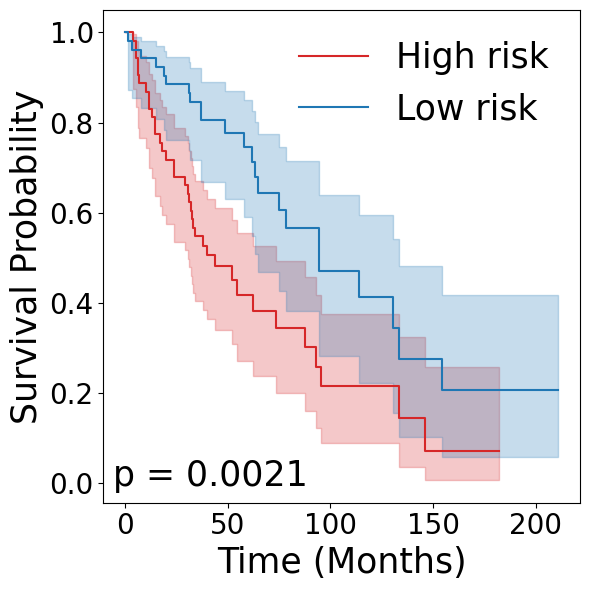

In [199]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import string 

# --- Configuration ---
color_high = '#D62728' # Red
color_low = '#1F77B4'  # Blue

kmf = KaplanMeierFitter()

print("\n--- Starting Individual Plot Analysis ---")

# Iterate directly through the list of pathways
for i, pathway in enumerate(pathways_to_analyze):
    
    # 1. Initialize a NEW Figure for every pathway
    #    Adjust figsize as needed (e.g., 6x6 is standard for single KM curves)
    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca() # Get current axis
    
    # --- 2. Data Prep ---
    median_score = female_pathway_df[pathway].median()
    
    # Create a copy to avoid SettingWithCopyWarnings
    plot_df = female_pathway_df.copy()
    
    plot_df['Current_Risk'] = plot_df[pathway].apply(
        lambda x: 'Low-Risk' if x > median_score else 'High-Risk'
    )
    
    T = plot_df['T']
    E = plot_df['E']
    ix_high = (plot_df['Current_Risk'] == 'High-Risk')
    ix_low = (plot_df['Current_Risk'] == 'Low-Risk')

    # --- 3. Plotting ---
    kmf.fit(T[ix_high], E[ix_high], label='High risk')
    kmf.plot_survival_function(ax=ax, color=color_high)
    
    kmf.fit(T[ix_low], E[ix_low], label='Low risk')
    kmf.plot_survival_function(ax=ax, color=color_low)

    # --- 4. Conditional P-Value Formatting ---
    results = logrank_test(T[ix_high], T[ix_low], E[ix_high], E[ix_low])
    p_val = results.p_value
    
    # Logic: Scientific if < 0.0001, else 4 decimals
    if p_val < 0.0001:
        p_text = f"p = {p_val:.2e}" 
    else:
        p_text = f"p = {p_val:.4f}" 

    # Place text at bottom-left
    ax.text(0.02, 0.02, p_text, 
            transform=ax.transAxes, 
            fontsize=25, 
            # fontweight='bold', 
            verticalalignment='bottom')

    # --- 5. Styling ---
    # Optional: Add 'A', 'B', 'C' tag if you still want to label them sequentially
    # ax.text(-0.1, 1.05, string.ascii_uppercase[i], transform=ax.transAxes, 
    #         fontsize=16, fontweight='bold')
    
    # ax.set_title(pathway, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    ax.set_xlabel('Time (Months)', fontsize=25)
    ax.set_ylabel('Survival Probability', fontsize=25)
    ax.legend(frameon=False, loc='upper right', fontsize=25)
    ax.grid(False)

    plt.tight_layout()
    
    # --- 6. Save or Show ---
    # Use a clean filename (replace spaces or special chars if necessary)
    clean_name = pathway.replace("/", "_").replace(" ", "_")
    
    # Uncomment the line below to save automatically:
    plt.savefig(f"Plot/{clean_name}_KM_Curve_byFemale.png", dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Close the plot to release memory before the next loop
    plt.close()